## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 20.11it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc


def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
    return newdf_a
        
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

## Formulas to run


In [5]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Code

## reg plots

In [6]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

KeyError: 'PI_Δg_OSAR'

## clustering code

In [6]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder', 'Speed ratio_Hg_OSAR',
       'Bout Speed ratio_Hg_OSAR'])
df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]

ntloblist = []
mbonloclst = []
df_nttotal = df_nt2.copy()
for n in df_nt2['MBON']:    
    ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_nttotal['NT'] = ntloblist
df_nttotal['Name'] = mbonloclst

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"]
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"]
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]
    
#g = sns.PairGrid(plot_data, vars=key_metrics, hue = 'NT')

In [7]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


In [30]:
mode = "single"

df_nta = df_neurotrans.drop(columns = ['responder', 'Name'])

df_allmbons = df_nta.set_index('MBON')
df_nt_singlecell = df_nta[df_nta['MBON'].isin(singlecellmbon)].set_index('MBON')
df_nt_multicell = df_nta[~df_nta['MBON'].isin(singlecellmbon)].set_index('MBON')

if mode == "single":
    specificdataset = df_nt_singlecell
    modename = "Single celled"
elif mode == "multi":
    specificdataset = df_nt_multicell
    modename = "Multi celled"
elif mode == "all":
    specificdataset = df_allmbons
    modename = "Single and Multi-celled"

# metricsidontwant = [ 'Pause position_Δg_Falling',  'Duration of bouts_Δg_Falling','Number of Bouts_Δg_Falling',   
#                     'Max velocity_Δg_Falling', 'Bout speed_Δg_Falling',  'Speed_Δg_Falling', 'Speed ratio_Hg_OSAR',
#                     'Bout Speed ratio_Hg_OSAR', 'genotypeandresponder']

metricsidontwant = [ 'Pause position_Δg_Falling',  'Duration of bouts_Δg_Falling','Number of Bouts_Δg_Falling',   
                    'Max velocity_Δg_Falling', 'Bout speed_Δg_Falling',  'Speed_Δg_Falling', 'Speed ratio_Hg_OSAR',
                    'Bout Speed ratio_Hg_OSAR', 'genotypeandresponder', 'PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']

datasettouse = specificdataset[[col for col in specificdataset.columns if col not in metricsidontwant]]

## UMAP

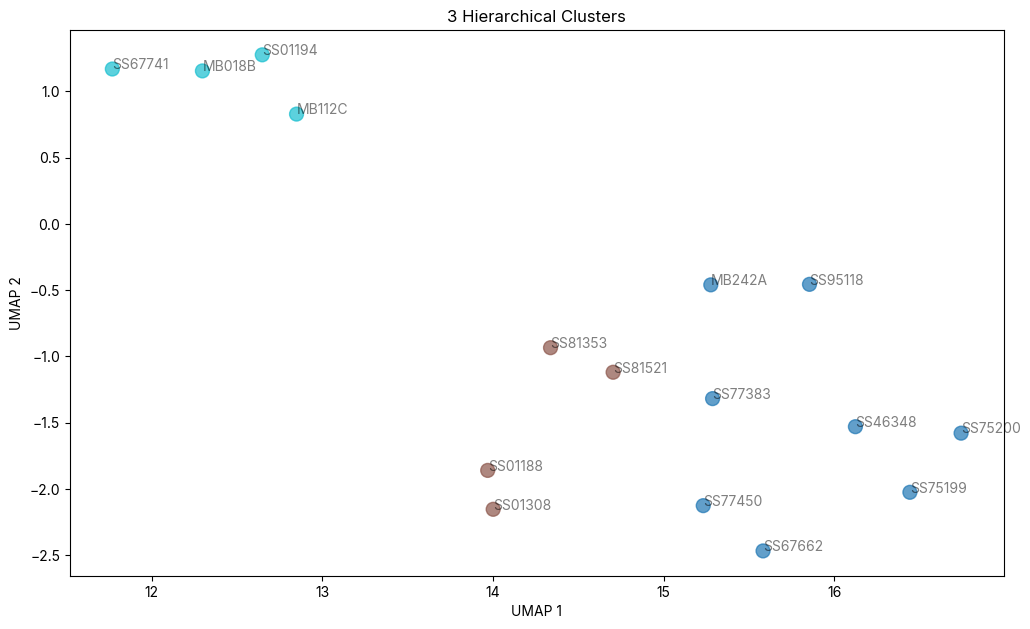

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap


valencemetricsonly = ['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']
valence_features = specificdataset[[col for col in specificdataset.columns if col in valencemetricsonly]]
MBON_names = specificdataset.index.tolist()

# Combine features with balanced weighting
motor_scaled = StandardScaler().fit_transform(datasettouse.drop(columns=["NT"]))
valence_scaled = StandardScaler().fit_transform(valence_features)

# Create balanced feature matrix
balanced_features = np.hstack([
    motor_scaled,
    valence_scaled * np.sqrt(len(datasettouse.columns)/2)  # Weight to balance dimensions
])

# Use UMAP for non-linear dimensionality reduction
reducer = umap.UMAP(n_components=2, n_neighbors=4, min_dist=0.1)
embedding = reducer.fit_transform(balanced_features)

plt.figure(figsize=(20, 12)) 

clusterer = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = clusterer.fit_predict(balanced_features)

# Plot UMAP colored by clusters
plt.subplot(2, 2, 3-1)
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=clusters, cmap='tab10', s=100, alpha=0.7)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.xticks([])
plt.yticks([])
plt.title('3 Hierarchical Clusters')

# Add MBON labels if you want
for i, mbon in enumerate(MBON_names):
    plt.annotate(mbon, (embedding[i, 0], embedding[i, 1]), 
                fontsize=10, alpha=0.5)

plt.tight_layout()
plt.show()

## Clustering valence and motor metrics

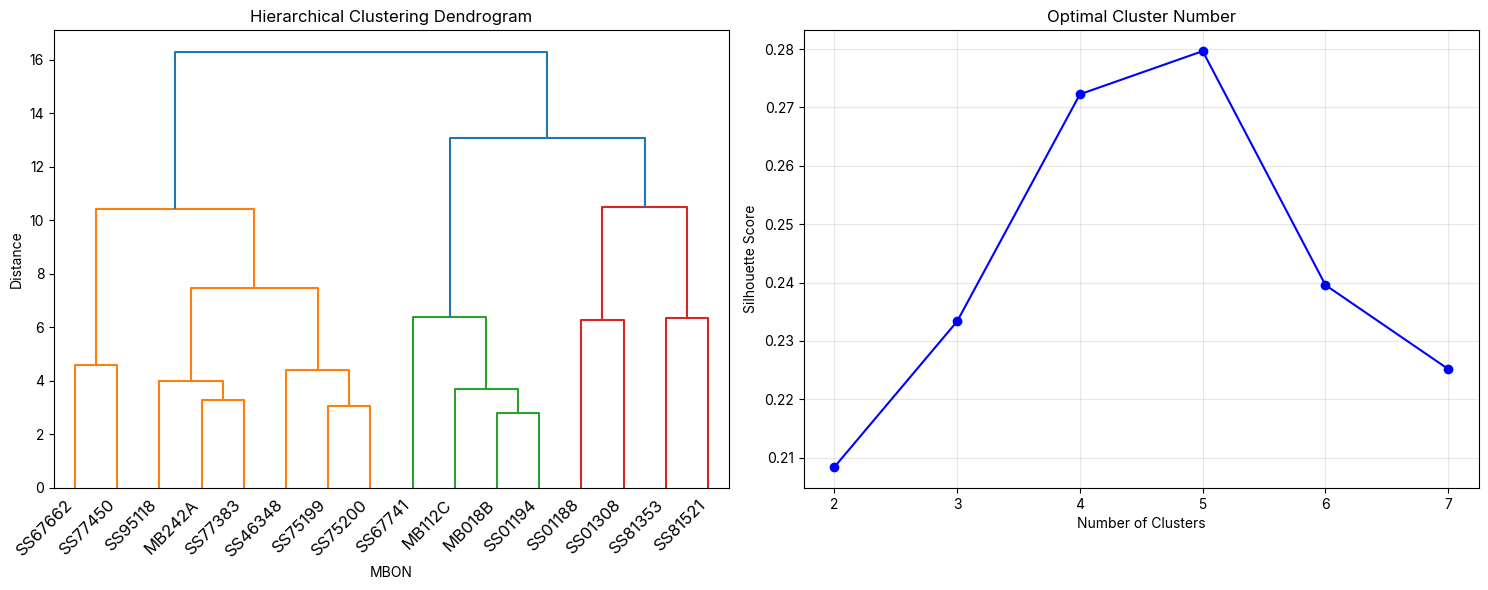

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare your data
motor_features = datasettouse.drop(columns=["NT"])
valence_features = specificdataset[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']]
MBON_names = specificdataset.index.tolist()

# Standardize and balance
motor_scaled = StandardScaler().fit_transform(motor_features)
valence_scaled = StandardScaler().fit_transform(valence_features)

# Balance the contribution (equal weight to motor and valence domains)
balanced_features = np.hstack([
    motor_scaled,
    valence_scaled * np.sqrt((len(motor_features)/2) ) # Scale up valence to match motor dimensionality
])

# Step 1: Determine optimal number of clusters using dendrogram
Z = linkage(balanced_features, method='ward', metric= 'euclidean')

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
dendrogram(Z, labels=MBON_names, orientation='top')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('MBON')
plt.ylabel('Distance')
plt.xticks(rotation=45, ha='right')

# Step 2: Try different numbers of clusters and evaluate
from sklearn.metrics import silhouette_score


silhouette_scores = []
for n_clusters in range(2, 8):
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    clusters = clusterer.fit_predict(balanced_features)
    score = silhouette_score(balanced_features, clusters)
    silhouette_scores.append(score)

plt.subplot(1, 2, 2)
plt.plot(range(2, 8), silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Optimal Cluster Number')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: Choose optimal number (let's say 4 based on your data)
optimal_n = 4 # Adjust based on silhouette score and dendrogram
clusterer = AgglomerativeClustering(n_clusters=optimal_n, linkage='ward')
final_clusters = clusterer.fit_predict(balanced_features)

In [ ]:
def interpret_motor_profile(cluster_data, motor_pca, motor_scaled):
    """
    Interpret motor patterns based on PC scores and loadings
    """
    # Get PC scores for this cluster
    cluster_indices = cluster_data.index
    cluster_motor_scaled = motor_scaled[cluster_indices]
    cluster_pc_scores = motor_pca.transform(cluster_motor_scaled)
    
    mean_pc1 = cluster_pc_scores[:, 0].mean()
    mean_pc2 = cluster_pc_scores[:, 1].mean()
    
    print(f"\n--- Motor Profile (PCA-based) ---")
    print(f"Mean PC1 score: {mean_pc1:.2f}")
    print(f"Mean PC2 score: {mean_pc2:.2f}")
    
    # Interpret based on your PC loadings
    motor_interpretation = []
    
    # PC1 interpretation (34.2% variance)
    # Positive PC1: High climbing, preserved OSAR speed, normal bout organization
    # Negative PC1: Reduced climbing, slower falling speed, longer bout durations
    if mean_pc1 > 1:
        motor_interpretation.append("Enhanced vertical climbing with preserved horizontal locomotion")
    elif mean_pc1 < -1:
        motor_interpretation.append("Impaired climbing with prolonged bout durations")
    
    # PC2 interpretation (25.1% variance)  
    # Positive PC2: High bout speed, max velocity ratio for falling, high speed ratio and max velocity ratio for horizontal walking
    # Negative PC2: Reduced bout speed in horizontal chamber, reduced number of bouts in horizontal climbing and reduced straightness index for falling
    if mean_pc2 > 1:
        motor_interpretation.append("Robust climbing efficiency with sustained horizontal walking")
    elif mean_pc2 < -1:
        motor_interpretation.append("Reduced Horizontal walking Performance With Increased Falling and Poor Trajectory Control")
    
    if not motor_interpretation:
        motor_interpretation.append("Normal motor coordination")
    
    return " + ".join(motor_interpretation), mean_pc1, mean_pc2


In [166]:
loadings['PC2']

Fall number_ΔΔ_Falling              -0.080803
Average height climbed_Δg_Falling   -0.055709
Straightness Index_Δg_Falling       -0.311810
Log2 Bout Speed ratio_Hg_Falling     0.489049
Log2 Speed ratio_Hg_Falling         -0.035179
Bout Number index_Hg_Falling        -0.374215
Bout Duration ratio_Hg_Falling       0.203127
Max Velocity ratio_Hg_Falling        0.416586
Log2 Speed ratio_Hg_OSAR             0.282212
Log2 Bout Speed ratio_Hg_OSAR       -0.384951
Bout Number Index_Hg_OSAR            0.056677
Bout Duration ratio_Hg_OSAR          0.089586
Max Velocity ratio_Hg_OSAR           0.242539
Name: PC2, dtype: float64

In [111]:
# First, run PCA on motor features
motor_pca = PCA()
motor_pca.fit(motor_scaled)
motor_pcs = motor_pca.transform(motor_scaled)

# Store loadings for reference
pc1_loadings = pd.Series(motor_pca.components_[0], index=motor_features.columns)
pc2_loadings = pd.Series(motor_pca.components_[1], index=motor_features.columns)

for cluster_id in range(optimal_n):
    cluster_mask = cluster_profiles['Cluster'] == cluster_id
    cluster_data = cluster_profiles[cluster_mask]
    
    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} (n={sum(cluster_mask)} MBONs)")
    print(f"{'='*40}")
    
    # List MBONs
    mbons_in_cluster = list(cluster_data['MBON'])
    print(f"MBONs: {', '.join(mbons_in_cluster)}")
    
    # Valence characteristics
    mean_pi = cluster_data['PI'].mean()
    mean_lai = cluster_data['LAI'].mean()
    
    print(f"\n--- Valence Profile ---")
    print(f"Mean PI: {mean_pi:.3f} ± {cluster_data['PI'].std():.3f}")
    print(f"Mean LAI: {mean_lai:.3f} ± {cluster_data['LAI'].std():.3f}")
    
    # Valence classification
    if abs(mean_pi) < 0.2 and abs(mean_lai) < 0.2:
        valence_type = "NEUTRAL"
    elif mean_pi > 0.2:
        valence_type = "APPROACH"
    elif mean_pi < -0.2:
        valence_type = "AVOIDANCE"
  
    
    # Get proper motor interpretation based on PCs
    motor_interpretation, pc1_score, pc2_score = interpret_motor_profile(
        cluster_data, motor_pca, motor_scaled
    )
    
    # Show which specific metrics drive this cluster's motor phenotype
    print(f"\n--- Key Motor Metrics (most deviant from population) ---")
    motor_cols = [col for col in motor_features.columns]
    
    deviations = {}
    for col in motor_cols:
        cluster_mean = cluster_data[col].mean()
        overall_mean = cluster_profiles[col].mean()
        overall_std = cluster_profiles[col].std()
        if overall_std > 0:
            z_score = (cluster_mean - overall_mean) / overall_std
            if abs(z_score) > 1:
                deviations[col] = (cluster_mean, z_score)
    
    # Sort by absolute z-score
    sorted_deviations = sorted(deviations.items(), key=lambda x: abs(x[1][1]), reverse=True)
    
    for metric, (value, z_score) in sorted_deviations[:5]:
        direction = "↑" if z_score > 0 else "↓"
        print(f"  {direction} {metric}: {value:.3f} (z={z_score:.2f})")
    
    # Overall biological interpretation
    print(f"\n--- Biological Interpretation ---")
    print(f"Valence: {valence_type}")
    print(f"Motor pattern: {motor_interpretation}")
    
    # Classify based on motor PCs using your descriptions
    if abs(pc1_score) < 0.5 and abs(pc2_score) < 0.5:
        if valence_type != "NEUTRAL":
            cluster_classification = "PURE VALENCE (no motor phenotype)"
        else:
            cluster_classification = "BASELINE (neutral valence and motor)"
    elif valence_type == "NEUTRAL":
        cluster_classification = "PURE MOTOR (no valence effect)"
    else:
        cluster_classification = "INTEGRATED (coupled valence-motor)"
    
    # Add specific interpretations based on PC positions --> please check this again
    if pc1_score < -1 and pc2_score < -1:
        specific_phenotype = "Global motor impairment (impaired climbing with reduced horizontal performance)"
    elif pc1_score > 1:
        specific_phenotype = "Climbing enhancers (enhanced climbing with preserved horizontal locomotion)"
    elif pc1_score < -1:
        specific_phenotype = "Bout disorganizers (impaired climbing with prolonged bout durations)"
    else:
        specific_phenotype = "Context-dependent motor modulation"
    
    print(f"Classification: {cluster_classification}")
    print(f"Specific phenotype: {specific_phenotype}")


CLUSTER 0 (n=8 MBONs)
MBONs: MB242A, SS46348, SS67662, SS75199, SS75200, SS77383, SS77450, SS95118

--- Valence Profile ---
Mean PI: -0.316 ± 0.203
Mean LAI: -0.165 ± 0.289

--- Motor Profile (PCA-based) ---
Mean PC1 score: 0.65
Mean PC2 score: 0.88

--- Key Motor Metrics (most deviant from population) ---

--- Biological Interpretation ---
Valence: AVOIDANCE
Motor pattern: Normal motor coordination
Classification: INTEGRATED (coupled valence-motor)
Specific phenotype: Context-dependent motor modulation

CLUSTER 1 (n=2 MBONs)
MBONs: SS81353, SS81521

--- Valence Profile ---
Mean PI: 0.129 ± 0.159
Mean LAI: -0.113 ± 0.304

--- Motor Profile (PCA-based) ---
Mean PC1 score: -4.68
Mean PC2 score: 1.19

--- Key Motor Metrics (most deviant from population) ---
  ↑ Bout Duration ratio_Hg_Falling: 0.913 (z=2.05)
  ↓ Average height climbed_Δg_Falling: -1.490 (z=-1.91)
  ↑ Log2 Speed ratio_Hg_Falling: 1.614 (z=1.90)
  ↓ Log2 Speed ratio_Hg_OSAR: -0.920 (z=-1.59)
  ↓ Straightness Index_Δg_Fallin

Text(0.5, 1.0, 'Valence vs Motor PC1')

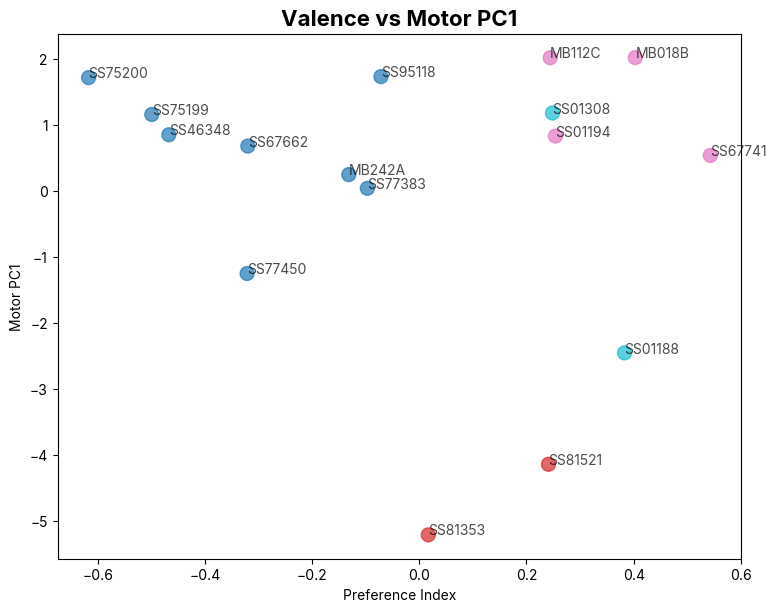

In [161]:
fig = plt.figure(figsize=(30, 15))


ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(cluster_profiles['PI'], motor_pcs[:, 0], 
                      c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
for i, mbon in enumerate(cluster_profiles['MBON']):
    ax2.annotate(mbon, (cluster_profiles['PI'][i], motor_pcs[i, 0]), fontsize=10, alpha=0.7)
    
ax2.set_xlabel('Preference Index')
ax2.set_ylabel('Motor PC1')
ax2.set_title('Valence vs Motor PC1', fontsize = 16, weight = "bold")


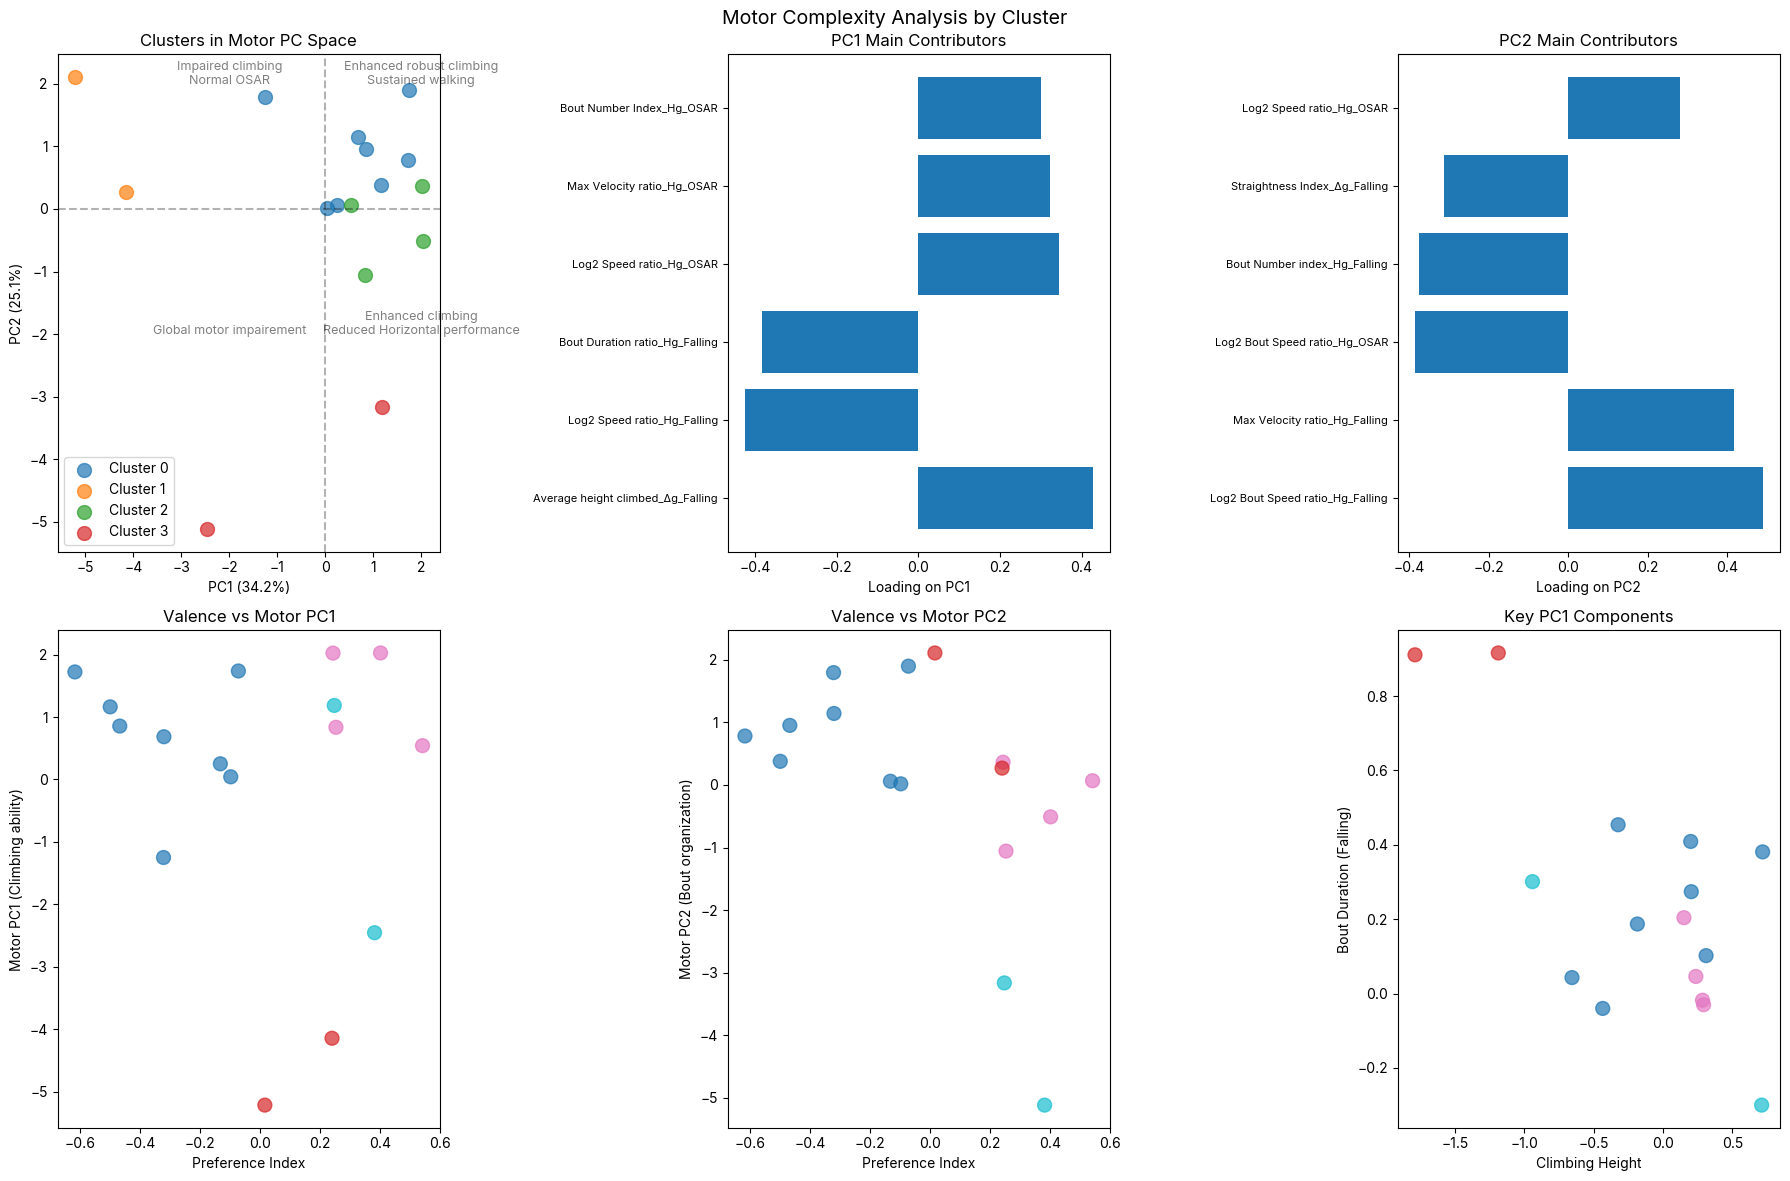

In [112]:
# Better visualization showing motor complexity
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Clusters in Motor PC space with annotations
ax = axes[0, 0]
for cluster_id in range(optimal_n):
    mask = cluster_profiles['Cluster'] == cluster_id
    ax.scatter(motor_pcs[mask, 0], motor_pcs[mask, 1], 
              label=f'Cluster {cluster_id}', s=100, alpha=0.7)

ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Add quadrant labels based on your PCA interpretation
# ax.text(2, 2, 'Enhanced climbing\nReduced OSAR', fontsize=9, alpha=0.5, ha='center')
# ax.text(2, -2, 'Enhanced climbing\nDisrupted bouts', fontsize=9, alpha=0.5, ha='center')
# ax.text(-2, 2, 'Slow falling\nNormal OSAR', fontsize=9, alpha=0.5, ha='center')
# ax.text(-2, -2, 'Impaired climbing\nDisorganized', fontsize=9, alpha=0.5, ha='center')

ax.text(2, 2, 'Enhanced robust climbing\nSustained walking', fontsize=9, alpha=0.5, ha='center')
ax.text(2, -2, 'Enhanced climbing\nReduced Horizontal performance', fontsize=9, alpha=0.5, ha='center')
ax.text(-2, 2, 'Impaired climbing\nNormal OSAR', fontsize=9, alpha=0.5, ha='center')
ax.text(-2, -2, 'Global motor impairement', fontsize=9, alpha=0.5, ha='center')

ax.set_xlabel(f'PC1 (34.2%)')
ax.set_ylabel(f'PC2 (25.1%)')
ax.set_title('Clusters in Motor PC Space')
ax.legend()

# 2. Show top contributing metrics for each PC
ax = axes[0, 1]
top_pc1 = pc1_loadings.abs().nlargest(6)
ax.barh(range(len(top_pc1)), pc1_loadings[top_pc1.index].values)
ax.set_yticks(range(len(top_pc1)))
ax.set_yticklabels(top_pc1.index, fontsize=8)
ax.set_xlabel('Loading on PC1')
ax.set_title('PC1 Main Contributors')

ax = axes[0, 2]
top_pc2 = pc2_loadings.abs().nlargest(6)
ax.barh(range(len(top_pc2)), pc2_loadings[top_pc2.index].values)
ax.set_yticks(range(len(top_pc2)))
ax.set_yticklabels(top_pc2.index, fontsize=8)
ax.set_xlabel('Loading on PC2')
ax.set_title('PC2 Main Contributors')

# 3. Valence vs Motor PC1
ax = axes[1, 0]
scatter = ax.scatter(cluster_profiles['PI'], motor_pcs[:, 0], 
                    c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
ax.set_xlabel('Preference Index')
ax.set_ylabel('Motor PC1 (Climbing ability)')
ax.set_title('Valence vs Motor PC1')

# 4. Valence vs Motor PC2
ax = axes[1, 1]
ax.scatter(cluster_profiles['PI'], motor_pcs[:, 1], 
          c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
ax.set_xlabel('Preference Index')
ax.set_ylabel('Motor PC2 (Bout organization)')
ax.set_title('Valence vs Motor PC2')

# 5. Context-specific plot
ax = axes[1, 2]
if 'Average height climbed_Δg_Falling' in cluster_profiles.columns:
    ax.scatter(cluster_profiles['Average height climbed_Δg_Falling'], 
              cluster_profiles['Bout Duration ratio_Hg_Falling'],
              c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
    ax.set_xlabel('Climbing Height')
    ax.set_ylabel('Bout Duration (Falling)')
    ax.set_title('Key PC1 Components')

plt.suptitle('Motor Complexity Analysis by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
# Create detailed cluster profiles
cluster_profiles = pd.DataFrame({
    'MBON': MBON_names,
    'Cluster': final_clusters,
    'PI': valence_features.iloc[:, 0].values,
    'LAI': valence_features.iloc[:, 1].values
})

# Add all motor metrics
for col in motor_features.columns:
    cluster_profiles[col] = motor_features[col].values

# Calculate cluster means and characteristics
print("\n" + "="*80)
print("CLUSTER CHARACTERIZATION")
print("="*80)

cluster_summaries = []

for cluster_id in range(optimal_n):
    cluster_mask = cluster_profiles['Cluster'] == cluster_id
    cluster_data = cluster_profiles[cluster_mask]
    
    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} (n={sum(cluster_mask)} MBONs)")
    print(f"{'='*40}")
    
    # List MBONs
    mbons_in_cluster = list(cluster_data['MBON'])
    print(f"MBONs: {', '.join(mbons_in_cluster)}")
    
    # Valence characteristics
    mean_pi = cluster_data['PI'].mean()
    mean_lai = cluster_data['LAI'].mean()
    
    print(f"\n--- Valence Profile ---")
    print(f"Mean PI: {mean_pi:.3f} ± {cluster_data['PI'].std():.3f}")
    print(f"Mean LAI: {mean_lai:.3f} ± {cluster_data['LAI'].std():.3f}")
    
    # Classify valence
    if abs(mean_pi) < 0.15 and abs(mean_lai) < 0.25:
        valence_type = "NEUTRAL"
    elif mean_pi > 0.3:
        valence_type = "STRONG APPROACH"
    elif mean_pi < -0.3:
        valence_type = "STRONG AVOIDANCE"
    else:
        valence_type = "MODERATE VALENCE"
    
    print(f"Valence Classification: {valence_type}")
    
    # Motor characteristics - find defining features
    print(f"\n--- Motor Profile ---")
    motor_cols = [col for col in cluster_profiles.columns if col not in ['MBON', 'Cluster', 'PI', 'LAI']]
    
    # Find most characteristic motor features (highest absolute z-score)
    defining_features = []
    for col in motor_cols:
        cluster_mean = cluster_data[col].mean()
        overall_mean = cluster_profiles[col].mean()
        overall_std = cluster_profiles[col].std()
        if overall_std > 0:
            z_score = (cluster_mean - overall_mean) / overall_std
            if abs(z_score) > 1:  # More than 1 SD from overall mean
                defining_features.append((col, cluster_mean, z_score))
    
    # Sort by absolute z-score
    defining_features.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print("Defining motor features (>1 SD from population mean):")
    for feat, val, z in defining_features[:5]:  # Top 5 features
        direction = "↑↑" if z > 1.5 else "↑" if z > 0 else "↓" if z > -1.5 else "↓↓"
        print(f"  {direction} {feat}: {val:.3f} (z={z:.2f})")
    
    # Biological interpretation
    print(f"\n--- Biological Interpretation ---")
    
    # Based on your specific metrics
    if 'Log2 Speed ratio_Hg_OSAR' in motor_cols:
        speed_osar = cluster_data['Log2 Speed ratio_Hg_OSAR'].mean()
        speed_falling = cluster_data['Log2 Speed ratio_Hg_Falling'].mean()
        
        if speed_osar < -0.5 and speed_falling < -0.5:
            motor_interpretation = "Reduced locomotion in both assays"
        elif speed_osar > 0.5 and speed_falling > 0.5:
            motor_interpretation = "Enhanced locomotion in both assays"
        elif abs(speed_osar - speed_falling) > 1:
            motor_interpretation = "Context-specific locomotion (OSAR vs Falling different)"
        else:
            motor_interpretation = "Normal locomotion"
    
    # Combine valence and motor for overall interpretation
    if valence_type == "NEUTRAL" and "Reduced" not in motor_interpretation:
        cluster_type = "PURE MOTOR"
    elif valence_type != "NEUTRAL" and motor_interpretation == "Normal locomotion":
        cluster_type = "PURE VALENCE"
    elif valence_type != "NEUTRAL" and motor_interpretation != "Normal locomotion":
        cluster_type = "INTEGRATED (VALENCE + MOTOR)"
    else:
        cluster_type = "BASELINE/NEUTRAL"
    
    print(f"Motor pattern: {motor_interpretation}")
    print(f"CLUSTER TYPE: {cluster_type}")
    
    cluster_summaries.append({
        'Cluster': cluster_id,
        'N': sum(cluster_mask),
        'Type': cluster_type,
        'Valence': valence_type,
        'Motor': motor_interpretation,
        'MBONs': ', '.join(mbons_in_cluster[:3]) + ('...' if len(mbons_in_cluster) > 3 else '')
    })


CLUSTER CHARACTERIZATION

CLUSTER 0 (n=8 MBONs)
MBONs: MB242A, SS46348, SS67662, SS75199, SS75200, SS77383, SS77450, SS95118

--- Valence Profile ---
Mean PI: -0.316 ± 0.203
Mean LAI: -0.165 ± 0.289
Valence Classification: STRONG AVOIDANCE

--- Motor Profile ---
Defining motor features (>1 SD from population mean):

--- Biological Interpretation ---
Motor pattern: Normal locomotion
CLUSTER TYPE: PURE VALENCE

CLUSTER 1 (n=2 MBONs)
MBONs: SS81353, SS81521

--- Valence Profile ---
Mean PI: 0.129 ± 0.159
Mean LAI: -0.113 ± 0.304
Valence Classification: NEUTRAL

--- Motor Profile ---
Defining motor features (>1 SD from population mean):
  ↑↑ Bout Duration ratio_Hg_Falling: 0.913 (z=2.05)
  ↓↓ Average height climbed_Δg_Falling: -1.490 (z=-1.91)
  ↑↑ Log2 Speed ratio_Hg_Falling: 1.614 (z=1.90)
  ↓↓ Log2 Speed ratio_Hg_OSAR: -0.920 (z=-1.59)
  ↓↓ Straightness Index_Δg_Falling: -1.024 (z=-1.54)

--- Biological Interpretation ---
Motor pattern: Context-specific locomotion (OSAR vs Falling diff

Text(0.5, 1.0, 'Clusters in Valence Space')

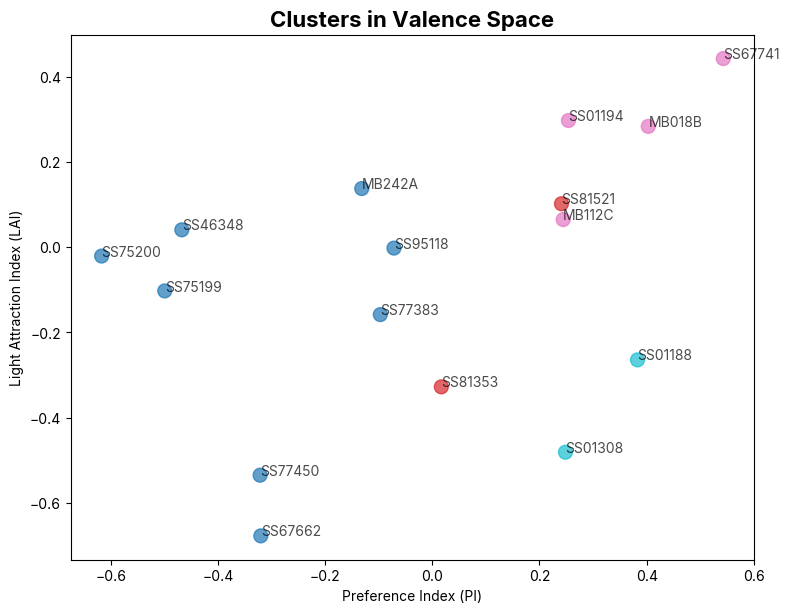

In [164]:
fig = plt.figure(figsize=(30, 15))

ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(cluster_profiles['PI'], cluster_profiles['LAI'], 
                     c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
for i, mbon in enumerate(MBON_names):
    ax1.annotate(mbon, (cluster_profiles.iloc[i]['PI'], cluster_profiles.iloc[i]['LAI']), 
                fontsize=10, alpha=0.7)

ax1.set_xlabel('Preference Index (PI)')
ax1.set_ylabel('Light Attraction Index (LAI)')
ax1.set_title('Clusters in Valence Space', fontsize = 16, weight = "bold")


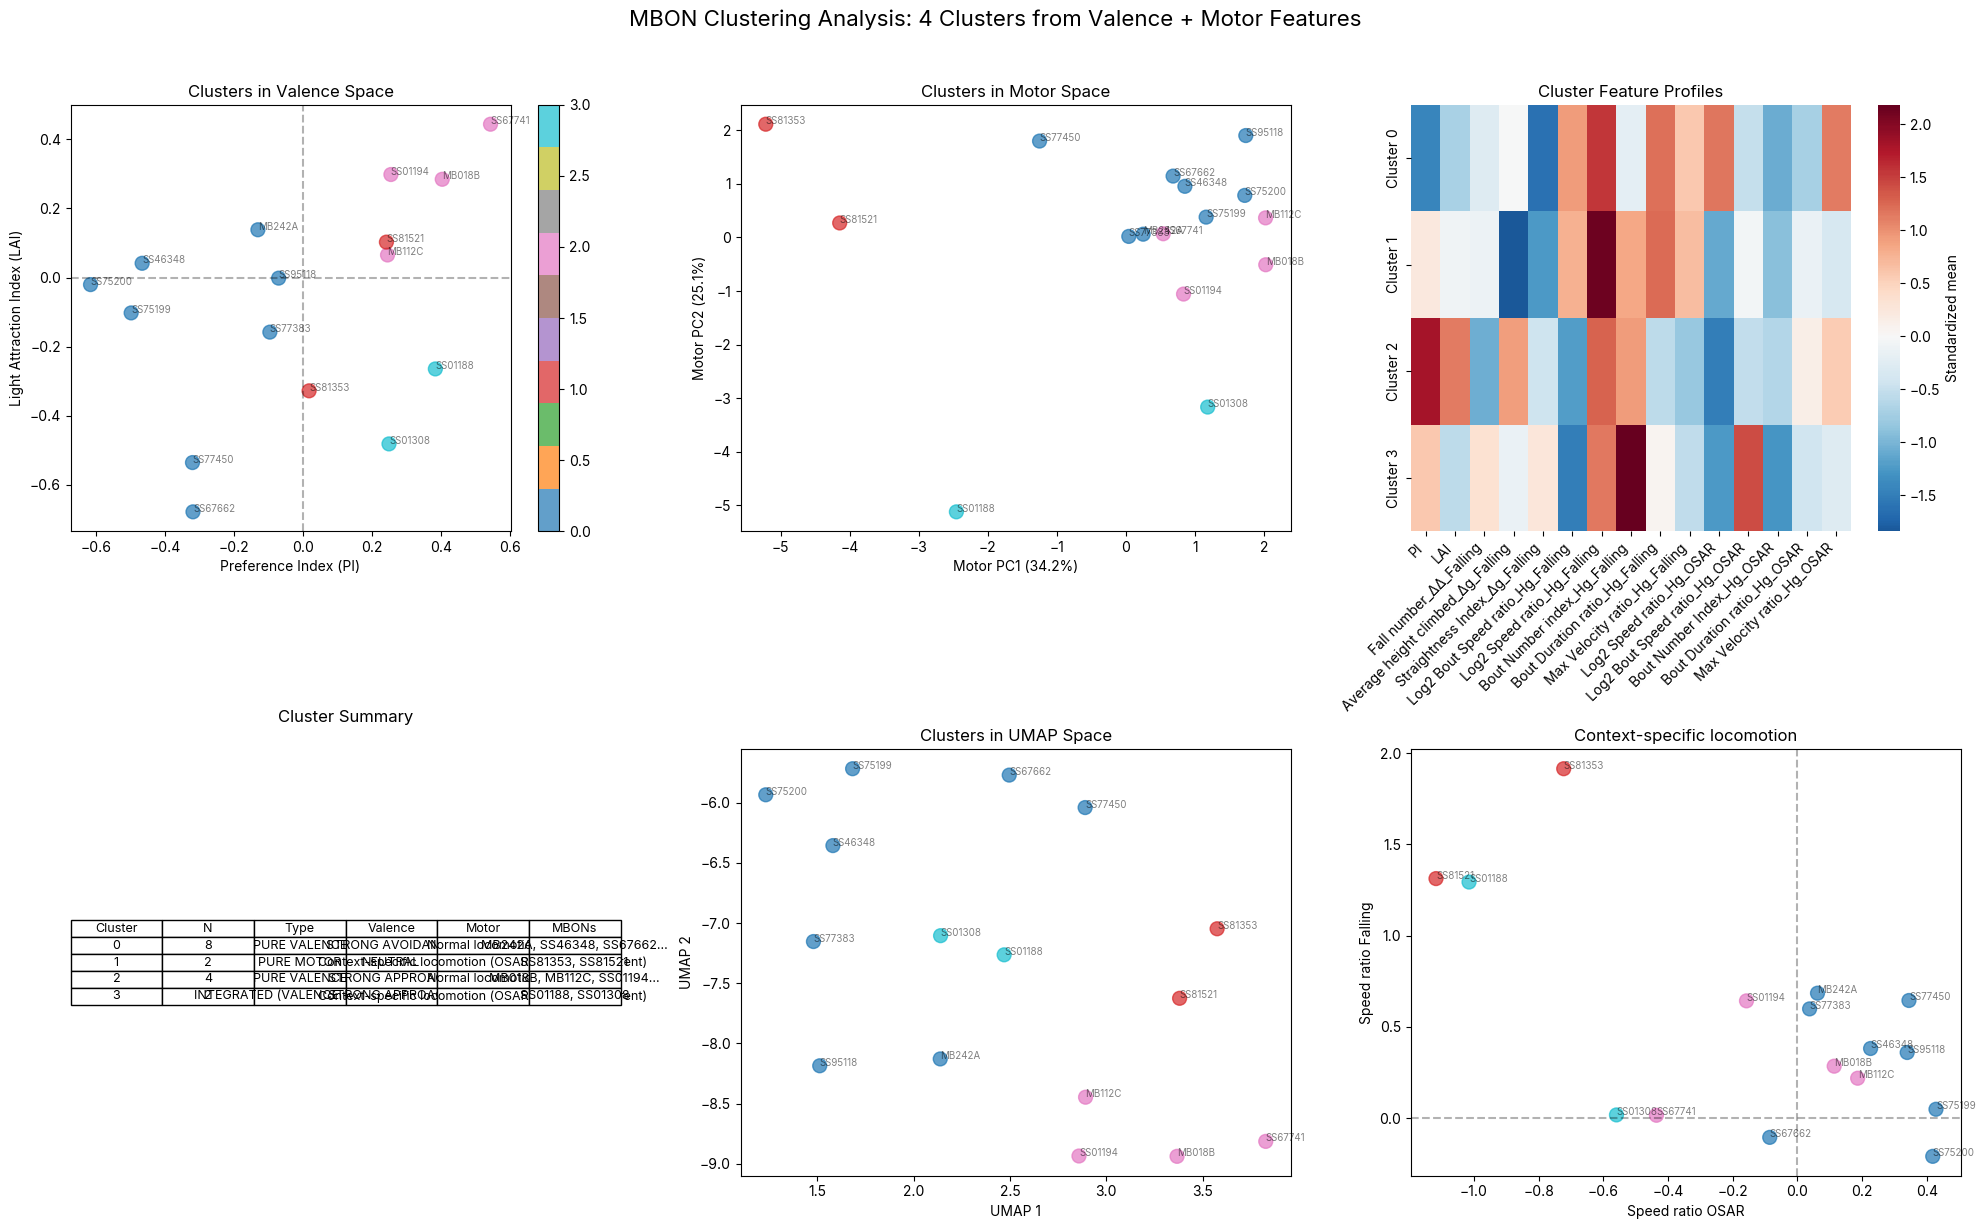

In [68]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))


# 1. Valence space
ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(cluster_profiles['PI'], cluster_profiles['LAI'], 
                     c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
for i, mbon in enumerate(MBON_names):
    ax1.annotate(mbon, (cluster_profiles.iloc[i]['PI'], cluster_profiles.iloc[i]['LAI']), 
                fontsize=7, alpha=0.5)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('Preference Index (PI)')
ax1.set_ylabel('Light Attraction Index (LAI)')
ax1.set_title('Clusters in Valence Space')
plt.colorbar(scatter, ax=ax1)

# 2. Motor PCA space
from sklearn.decomposition import PCA
motor_pca = PCA(n_components=2)
motor_pcs = motor_pca.fit_transform(motor_scaled)

ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(motor_pcs[:, 0], motor_pcs[:, 1], 
                      c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
for i, mbon in enumerate(MBON_names):
    ax2.annotate(mbon, (motor_pcs[i, 0], motor_pcs[i, 1]), fontsize=7, alpha=0.5)
ax2.set_xlabel(f'Motor PC1 ({motor_pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'Motor PC2 ({motor_pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('Clusters in Motor Space')

# 3. Heatmap of all features by cluster
ax3 = plt.subplot(2, 3, 3)
# Calculate mean values for each cluster
heatmap_data = []
feature_names = ['PI', 'LAI'] + list(motor_features.columns)

for cluster_id in range(optimal_n):
    cluster_mask = cluster_profiles['Cluster'] == cluster_id
    cluster_means = []
    for feat in feature_names:
        if feat in cluster_profiles.columns:
            cluster_means.append(cluster_profiles[cluster_mask][feat].mean())
    heatmap_data.append(cluster_means)

# Standardize for visualization
heatmap_data = StandardScaler().fit_transform(np.array(heatmap_data).T).T

sns.heatmap(heatmap_data, xticklabels=feature_names, 
            yticklabels=[f'Cluster {i}' for i in range(optimal_n)],
            cmap='RdBu_r', center=0, ax=ax3, cbar_kws={'label': 'Standardized mean'})
ax3.set_title('Cluster Feature Profiles')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Summary table
ax4 = plt.subplot(2, 3, 4)
ax4.axis('tight')
ax4.axis('off')
summary_df = pd.DataFrame(cluster_summaries)
table = ax4.table(cellText=summary_df.values, colLabels=summary_df.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
ax4.set_title('Cluster Summary', pad=20)

# 5. UMAP visualization
ax5 = plt.subplot(2, 3, 5)
import umap
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(balanced_features)
scatter5 = ax5.scatter(embedding[:, 0], embedding[:, 1], 
                      c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
for i, mbon in enumerate(MBON_names):
    ax5.annotate(mbon, (embedding[i, 0], embedding[i, 1]), fontsize=7, alpha=0.5)
ax5.set_xlabel('UMAP 1')
ax5.set_ylabel('UMAP 2')
ax5.set_title('Clusters in UMAP Space')

# 6. Specific metric comparisons
ax6 = plt.subplot(2, 3, 6)
x_metric = 'Log2 Speed ratio_Hg_OSAR'
y_metric = 'Log2 Speed ratio_Hg_Falling'
if x_metric in cluster_profiles.columns and y_metric in cluster_profiles.columns:
    scatter6 = ax6.scatter(cluster_profiles[x_metric], cluster_profiles[y_metric],
                          c=cluster_profiles['Cluster'], cmap='tab10', s=100, alpha=0.7)
    for i, mbon in enumerate(MBON_names):
        ax6.annotate(mbon, (cluster_profiles.iloc[i][x_metric], 
                           cluster_profiles.iloc[i][y_metric]), fontsize=7, alpha=0.5)
    ax6.set_xlabel('Speed ratio OSAR')
    ax6.set_ylabel('Speed ratio Falling')
    ax6.set_title('Context-specific locomotion')
    ax6.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax6.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.suptitle(f'MBON Clustering Analysis: {optimal_n} Clusters from Valence + Motor Features', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Pairplot

In [72]:
metriccolumns = ['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Max height climbed_Δg_Falling', 'Bout speed_Δg_Falling', 'Pause position_Δg_Falling',
       'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 
       
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR', 'NT']

df_nt_metricreduce = datasettouse[metriccolumns]

In [73]:
import pandas as pd
from scipy.stats import pearsonr
import itertools

# Get all pairwise combinations of your 16 variables
variables = df_nt_metricreduce.columns.tolist()[:-1]  # Adjust if you need to exclude some columns

results = []

# Calculate Pearson correlation for each pair
for var1, var2 in itertools.combinations(variables, 2):
    # Remove NaN values for each pair
    mask = df_nt_metricreduce[[var1, var2]].notna().all(axis=1)
    x = df_nt_metricreduce.loc[mask, var1]
    y = df_nt_metricreduce.loc[mask, var2]
    
    if len(x) > 0:  # Make sure we have data
        r, _ = pearsonr(x, y)
        r_squared = r ** 2
        results.append({
            'Metric 1': var1,
            'Metric 2': var2,
            'Pearson Coefficient': r,
            'R2': r_squared
        })


correlation_table = pd.DataFrame(results)
correlation_table = correlation_table.sort_values('R2', ascending=False).reset_index(drop=True)

#correlation_table.to_csv('pearson_correlations.csv', index=False)


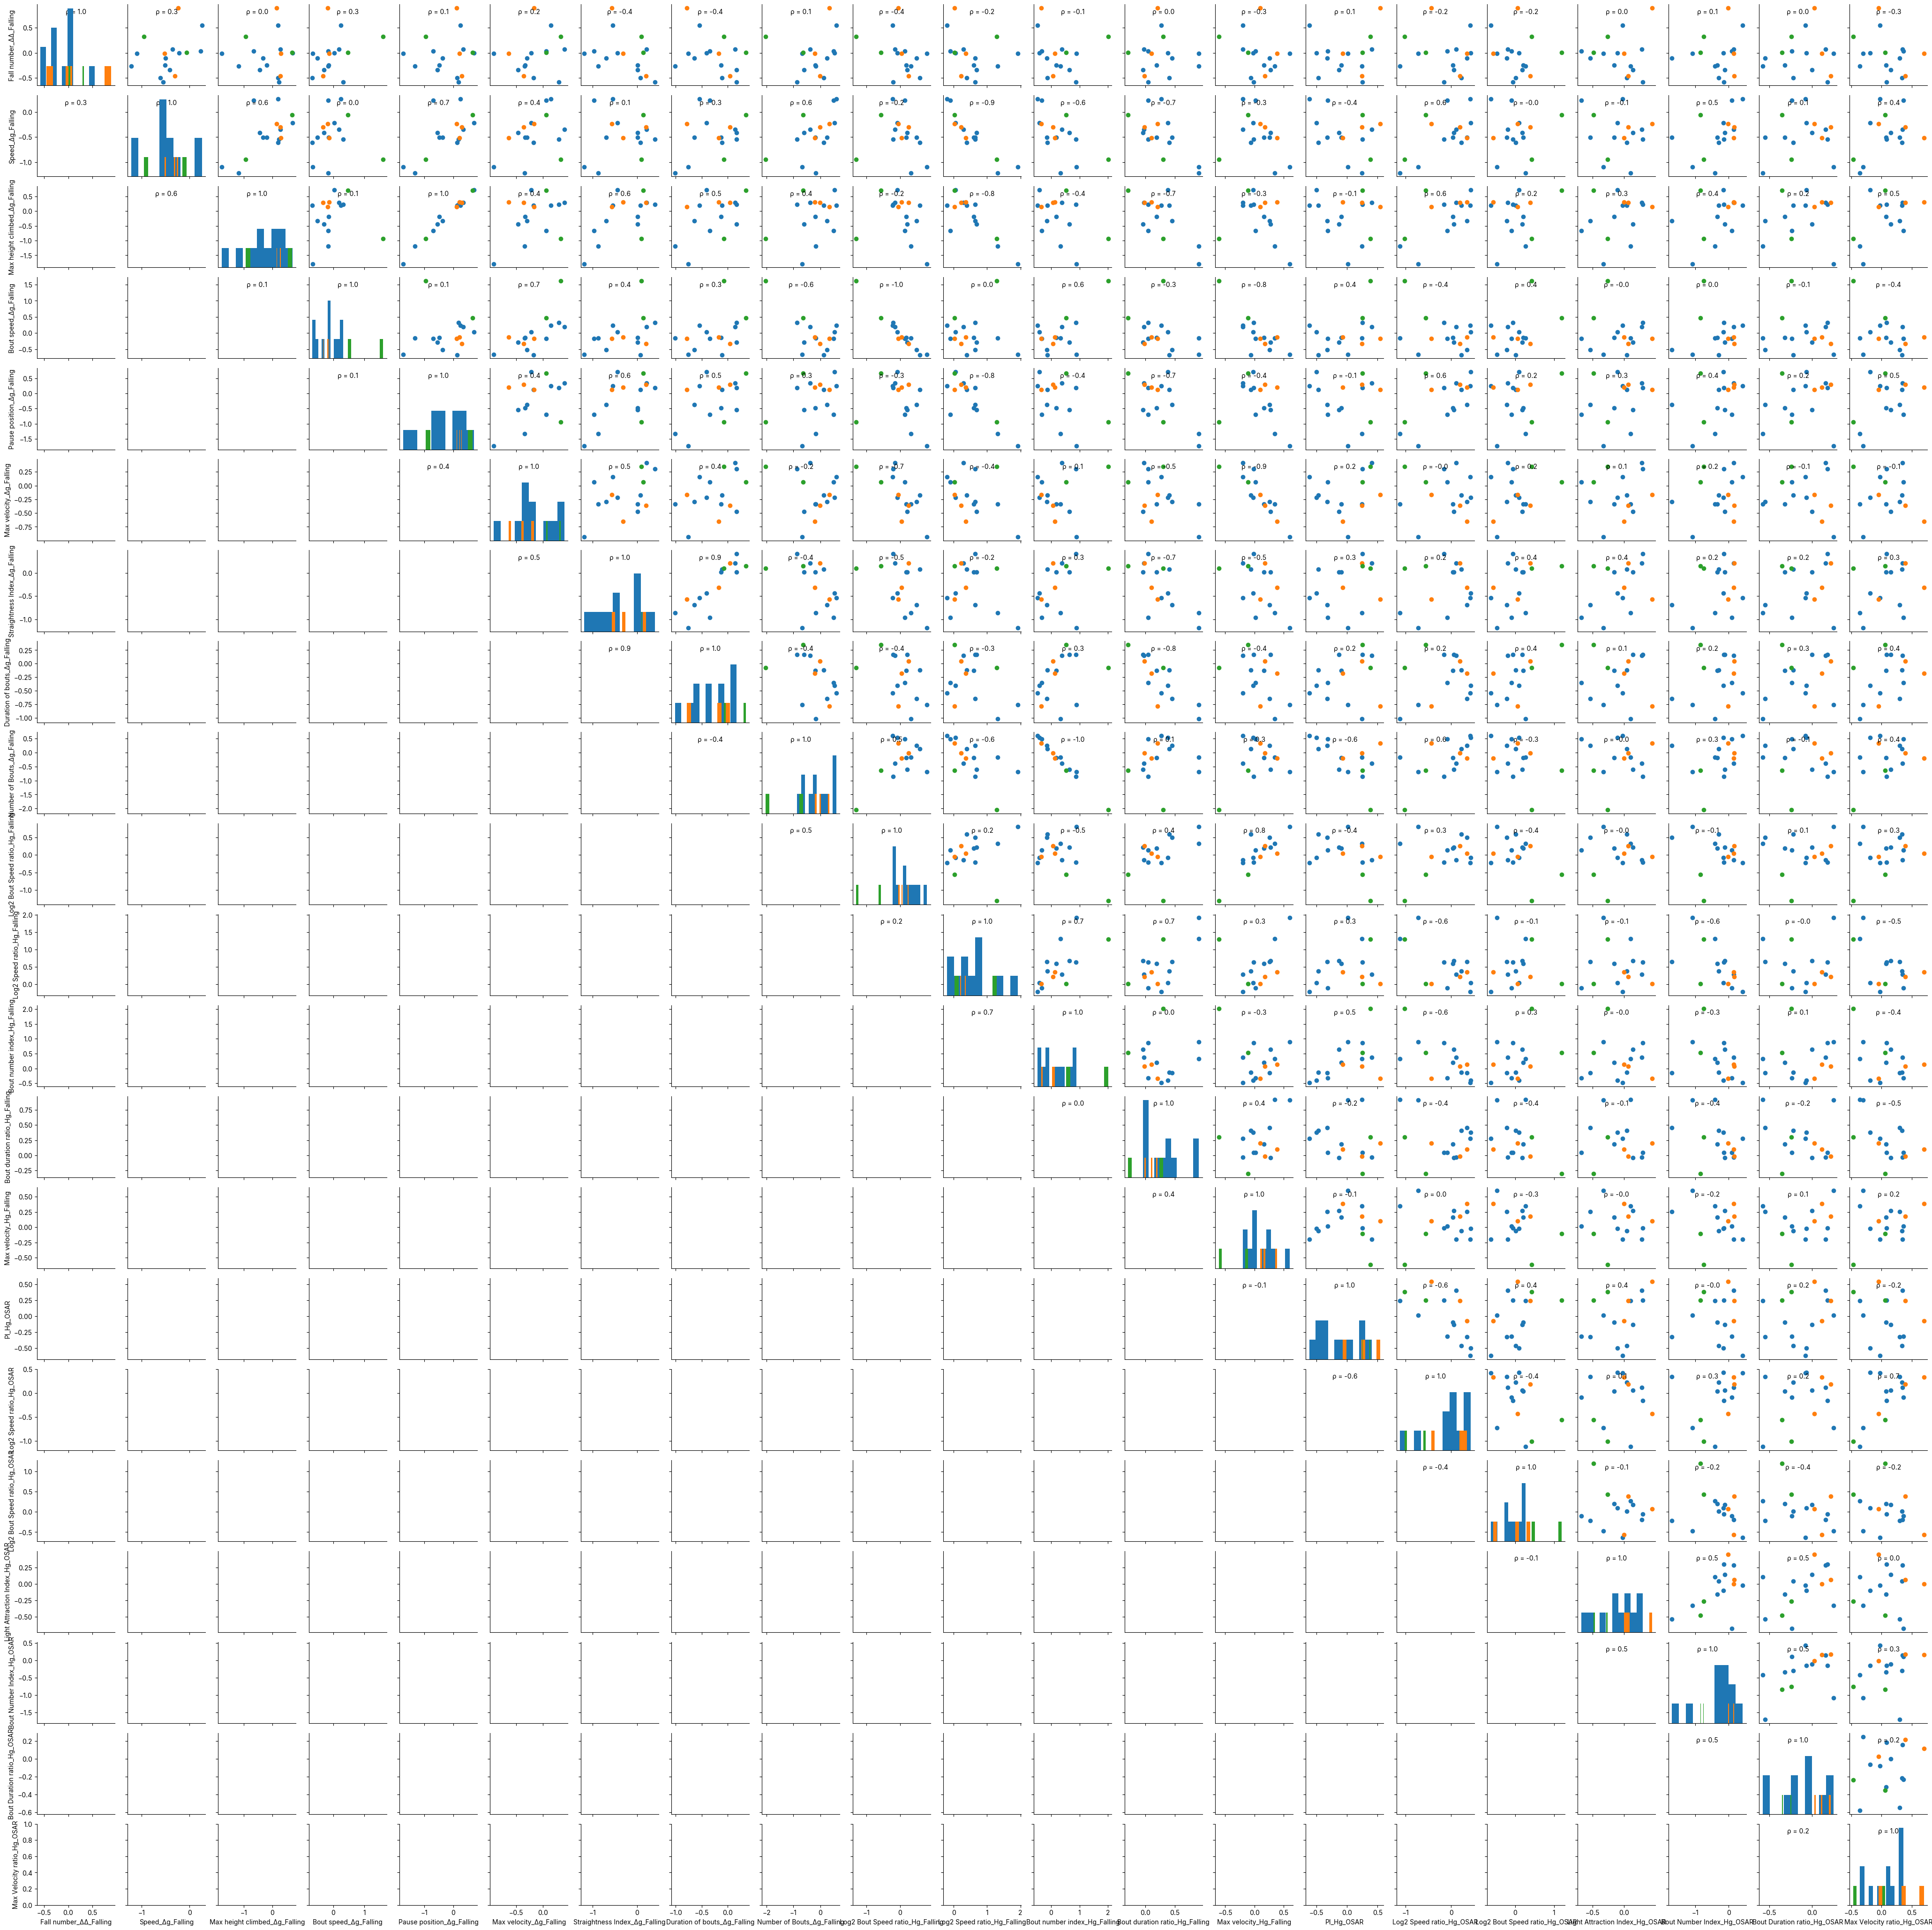

In [34]:
g = sns.PairGrid(df_nt_singlecell, hue = 'NT',height = 2.0)
g.map_diag(plt.hist)
g.map_upper(plt.scatter)
# g.map_lower(corrfunc)

for i, j in zip(*np.triu_indices_from(g.axes, k=-1)):
    corrfunc(df_nt_singlecell.iloc[:, j], 
             df_nt_singlecell.iloc[:, i], 
             ax=g.axes[i, j])

In [ ]:
fig, axes = plt.subplots(figsize=(16,4))
## code taken from another msvcode
df89 = pd.melt(df50, id_vars = ['Neurotransmitter'], var_name = 'Metrics', value_name = "Δg")
g1 = sns.swarmplot(data=df89, x= 'Metrics', y = 'Δg', hue='Neurotransmitter',dodge = True)
sns.move_legend(g1, "upper left", bbox_to_anchor=(1, 1))
sns.set_style("darkgrid")
wrap_labels(axes, 10)

## Clustering from Claude

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


df_clustermbons = datasettouse.copy()
df_cluster = df_clustermbons.drop(columns=['NT'])  # Keep ALL behavioral metrics
df_cluster = df_cluster.fillna(0)

# Optional: Apply effect size filter per MBON (not per metric)
# Keep MBONs that have at least ONE meaningful effect
min_effect_threshold = 0.2
mask = (df_cluster.abs() > min_effect_threshold).any(axis=1)
df_filtered = df_cluster[mask]
print(f"MBONs with at least one |Δg| > {min_effect_threshold}: {len(df_filtered)}/{len(df_cluster)}")

# 2. STANDARDIZE ALL METRICS
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_filtered)
print(f"Clustering on {data_scaled.shape[0]} MBONs × {data_scaled.shape[1]} metrics")

# 3. DETERMINE OPTIMAL CLUSTERS
# Method 1: Silhouette analysis
silhouette_scores = []
K_range = range(2, min(10, len(df_filtered)//2))

for k in K_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = clusterer.fit_predict(data_scaled)
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k by Silhouette: {optimal_k}")

# Method 2: Dendrogram inspection
linkage_matrix = linkage(data_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=df_filtered.index.tolist(),
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram - All Metrics')
plt.xlabel('MBON')
plt.ylabel('Ward Distance')

# Add horizontal lines at different cut heights
for k in [3, 4, 5]:
    threshold = linkage_matrix[-k, 2]
    plt.axhline(y=threshold, c='r', linestyle='--', alpha=0.5, 
                label=f'{k+1} clusters')
plt.legend()
plt.tight_layout()
plt.show()

# 4. ANALYZE CLUSTER STABILITY
# Try different linkage methods to see if clusters are robust
linkage_methods = ['ward', 'average', 'complete']
results_comparison = {}

for method in linkage_methods:
    link_matrix = linkage(data_scaled, method=method)
    clusters = fcluster(link_matrix, optimal_k, criterion='maxclust')
    sil_score = silhouette_score(data_scaled, clusters)
    results_comparison[method] = {
        'clusters': clusters,
        'silhouette': sil_score
    }
    print(f"{method}: Silhouette = {sil_score:.3f}")

# 5. FINAL CLUSTERING WITH BEST METHOD
best_method = max(results_comparison, key=lambda x: results_comparison[x]['silhouette'])
final_clusters = results_comparison[best_method]['clusters']

df_clustered = df_filtered.copy()
df_clustered['Cluster'] = final_clusters

# 6. CHARACTERIZE CLUSTERS
# Look at mean effect sizes per cluster across ALL metrics
cluster_profiles = df_clustered.groupby('Cluster').mean()

# Heatmap of cluster profiles
plt.figure(figsize=(20, 6))
sns.heatmap(cluster_profiles.T, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Δg'}, 
            xticklabels=[f'Cluster {i}' for i in cluster_profiles.index],
            yticklabels=cluster_profiles.columns)
plt.title('Cluster Behavioral Profiles - All Metrics')
plt.tight_layout()
plt.show()

# 7. IDENTIFY WHAT MAKES EACH CLUSTER UNIQUE
for cluster_id in cluster_profiles.index:
    print(f"\nCluster {cluster_id} characteristics:")
    profile = cluster_profiles.loc[cluster_id]
    
    # Find strongest effects (positive and negative)
    top_positive = profile.nlargest(3)
    top_negative = profile.nsmallest(3)
    
    print("Strongest positive effects:")
    for metric, value in top_positive.items():
        if value > 0.2:
            print(f"  {metric}: {value:.2f}")
    
    print("Strongest negative effects:")
    for metric, value in top_negative.items():
        if value < -0.2:
            print(f"  {metric}: {value:.2f}")
    
    # Classify behaviorally
    osar_effects = profile[[col for col in profile.index if 'OSAR' in col]].abs().mean()
    falling_effects = profile[[col for col in profile.index if 'Falling' in col]].abs().mean()
    
    if osar_effects > 0.3 and falling_effects < 0.2:
        category = "OSAR-dominant"
    elif falling_effects > 0.3 and osar_effects < 0.2:
        category = "Falling-dominant"
    elif osar_effects > 0.2 and falling_effects > 0.2:
        category = "Multi-context"
    else:
        category = "Weak/Modulatory"
    
    print(f"Behavioral category: {category}")
    print(f"MBONs in cluster: {(df_clustered['Cluster'] == cluster_id).sum()}")

In [ ]:
# 1. Let the hierarchical clustering define the groups
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = hierarchical.fit_predict(data_scaled)

# 2. Look at the RAW patterns for each cluster
# Don't average or categorize yet - just observe
for cluster_id in range(3):
    cluster_mbons = df_clustered[df_clustered['Cluster'] == cluster_id]
    
    print(f"\nCluster {cluster_id + 1}:")
    print(f"Number of MBONs: {len(cluster_mbons)}")
    
    # Show the actual mean values for EACH metric separately
    print("\nMean Δg values:")
    for metric in df_clustered.columns:
        if metric != 'Cluster':
            mean_val = cluster_mbons[metric].mean()
            std_val = cluster_mbons[metric].std()
            print(f"  {metric}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Let the pattern speak for itself
    # Don't force categories

## NT code

In [138]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Prepare data for clustering
df_clustermbons = datasettouse.copy()
df_cluster = df_clustermbons.drop(columns=['NT']).fillna(0)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_cluster)

# Apply 4 clustering methods
n_clusters = 4

# K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(data_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Gaussian Mixture
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(data_scaled)

# Calculate silhouette scores
sil_kmeans = silhouette_score(data_scaled, kmeans_labels)
sil_hierarchical = silhouette_score(data_scaled, hierarchical_labels)
sil_dbscan = silhouette_score(data_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
sil_gmm = silhouette_score(data_scaled, gmm_labels)

# Create results dataframe
results = pd.DataFrame({
    'Method': ['K-means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Silhouette Score': [sil_kmeans, sil_hierarchical, sil_dbscan, sil_gmm],
    'N Clusters': [len(set(kmeans_labels)), len(set(hierarchical_labels)), 
                   len(set(dbscan_labels)), len(set(gmm_labels))]
})

print("Clustering Comparison Results:")
print(results.sort_values('Silhouette Score', ascending=False))

best_method = results.loc[results['Silhouette Score'].idxmax(), 'Method']
print(f"\nBest method: {best_method}")

# Add cluster labels to dataframe
df_clustermbons_clustered = df_clustermbons.copy()
df_clustermbons_clustered['KMeans'] = kmeans_labels
df_clustermbons_clustered['Hierarchical'] = hierarchical_labels
df_clustermbons_clustered['DBSCAN'] = dbscan_labels
df_clustermbons_clustered['GMM'] = gmm_labels

# Compare with neurotransmitter types
print("\nClustering vs Neurotransmitter Alignment:")
for method, labels in [('KMeans', kmeans_labels), ('Hierarchical', hierarchical_labels), 
                       ('DBSCAN', dbscan_labels), ('GMM', gmm_labels)]:
    ari = adjusted_rand_score(df_clustermbons['NT'].factorize()[0], labels)
    print(f"{method}: ARI = {ari:.3f}")

# PCA for visualization 
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
df_clustermbons_clustered['PCA1'] = pca_data[:, 0]
df_clustermbons_clustered['PCA2'] = pca_data[:, 1]

Clustering Comparison Results:
         Method  Silhouette Score  N Clusters
1  Hierarchical          0.168866           4
0       K-means          0.164855           4
3           GMM          0.164855           4
2        DBSCAN         -1.000000           1

Best method: Hierarchical

Clustering vs Neurotransmitter Alignment:
KMeans: ARI = 0.110
Hierarchical: ARI = -0.006
DBSCAN: ARI = 0.000
GMM: ARI = 0.110


## Original hierarchical clustering

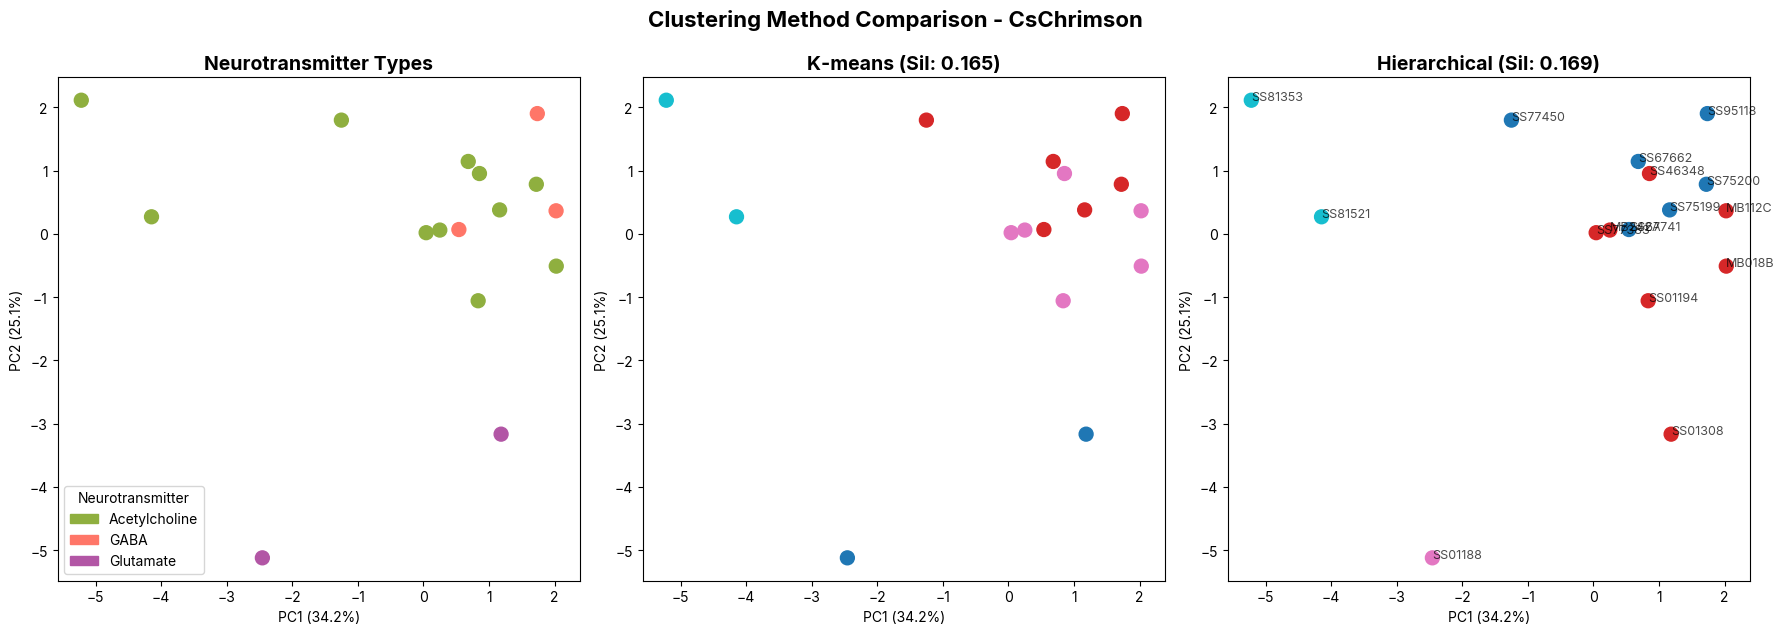

In [139]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#colors for plot 1
nt_color_map = {
    'Acetylcholine': "#8FAF3F",  # Red
    'GABA': "#FF7668",           # Purple
    'Glutamate': "#B256A5"       # Brown
}

nt_cat = df_clustermbons_clustered['NT'].astype('category')
point_colors = [nt_color_map[nt] for nt in df_clustermbons_clustered['NT']]

# Neurotransmitter types (reference)
axes[0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=point_colors, s=100)
axes[0].set_title('Neurotransmitter Types', fontsize=14, weight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

handles = [mpatches.Patch(color=nt_color_map[nt], label=nt) 
           for nt in nt_cat.cat.categories]
axes[0].legend(handles=handles, title='Neurotransmitter')

# K-means
axes[1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['KMeans'], cmap='tab10', s=100)
axes[1].set_title(f'K-means (Sil: {sil_kmeans:.3f})', fontsize=14, weight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Hierarchical
axes[2].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['Hierarchical'], cmap='tab10', s=100)
axes[2].set_title(f'Hierarchical (Sil: {sil_hierarchical:.3f})', fontsize=14, weight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Results table
# axes[1,1].axis('off')
# table_data = results.sort_values('Silhouette Score', ascending=False).round(3)
# table = axes[1,1].table(cellText=table_data.values, colLabels=table_data.columns,
#                         cellLoc='center', loc='center')
# table.auto_set_font_size(False)
# table.set_fontsize(12)
# table.scale(1, 2)
# axes[1,1].set_title('Performance Comparison', fontsize=14, weight='bold')

best_ax = None
if best_method == 'K-means':
    best_ax = axes[1]
elif best_method == 'Hierarchical': 
    best_ax = axes[2]
# elif best_method == 'DBSCAN':
#     best_ax = axes[1,0]
# elif best_method == 'GMM':
#     best_ax = axes[1,1]

if best_ax is not None:
    for i, mbon in enumerate(df_clustermbons_clustered.index):
        best_ax.annotate(mbon, (df_clustermbons_clustered['PCA1'].iloc[i], df_clustermbons_clustered['PCA2'].iloc[i]), 
                        fontsize=9, alpha=0.7)

plt.tight_layout()
plt.suptitle(f'Clustering Method Comparison - ' + responderrename, fontsize=16, weight='bold', y=1.05)
#plt.savefig(filesavedir + date + '_clustering_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

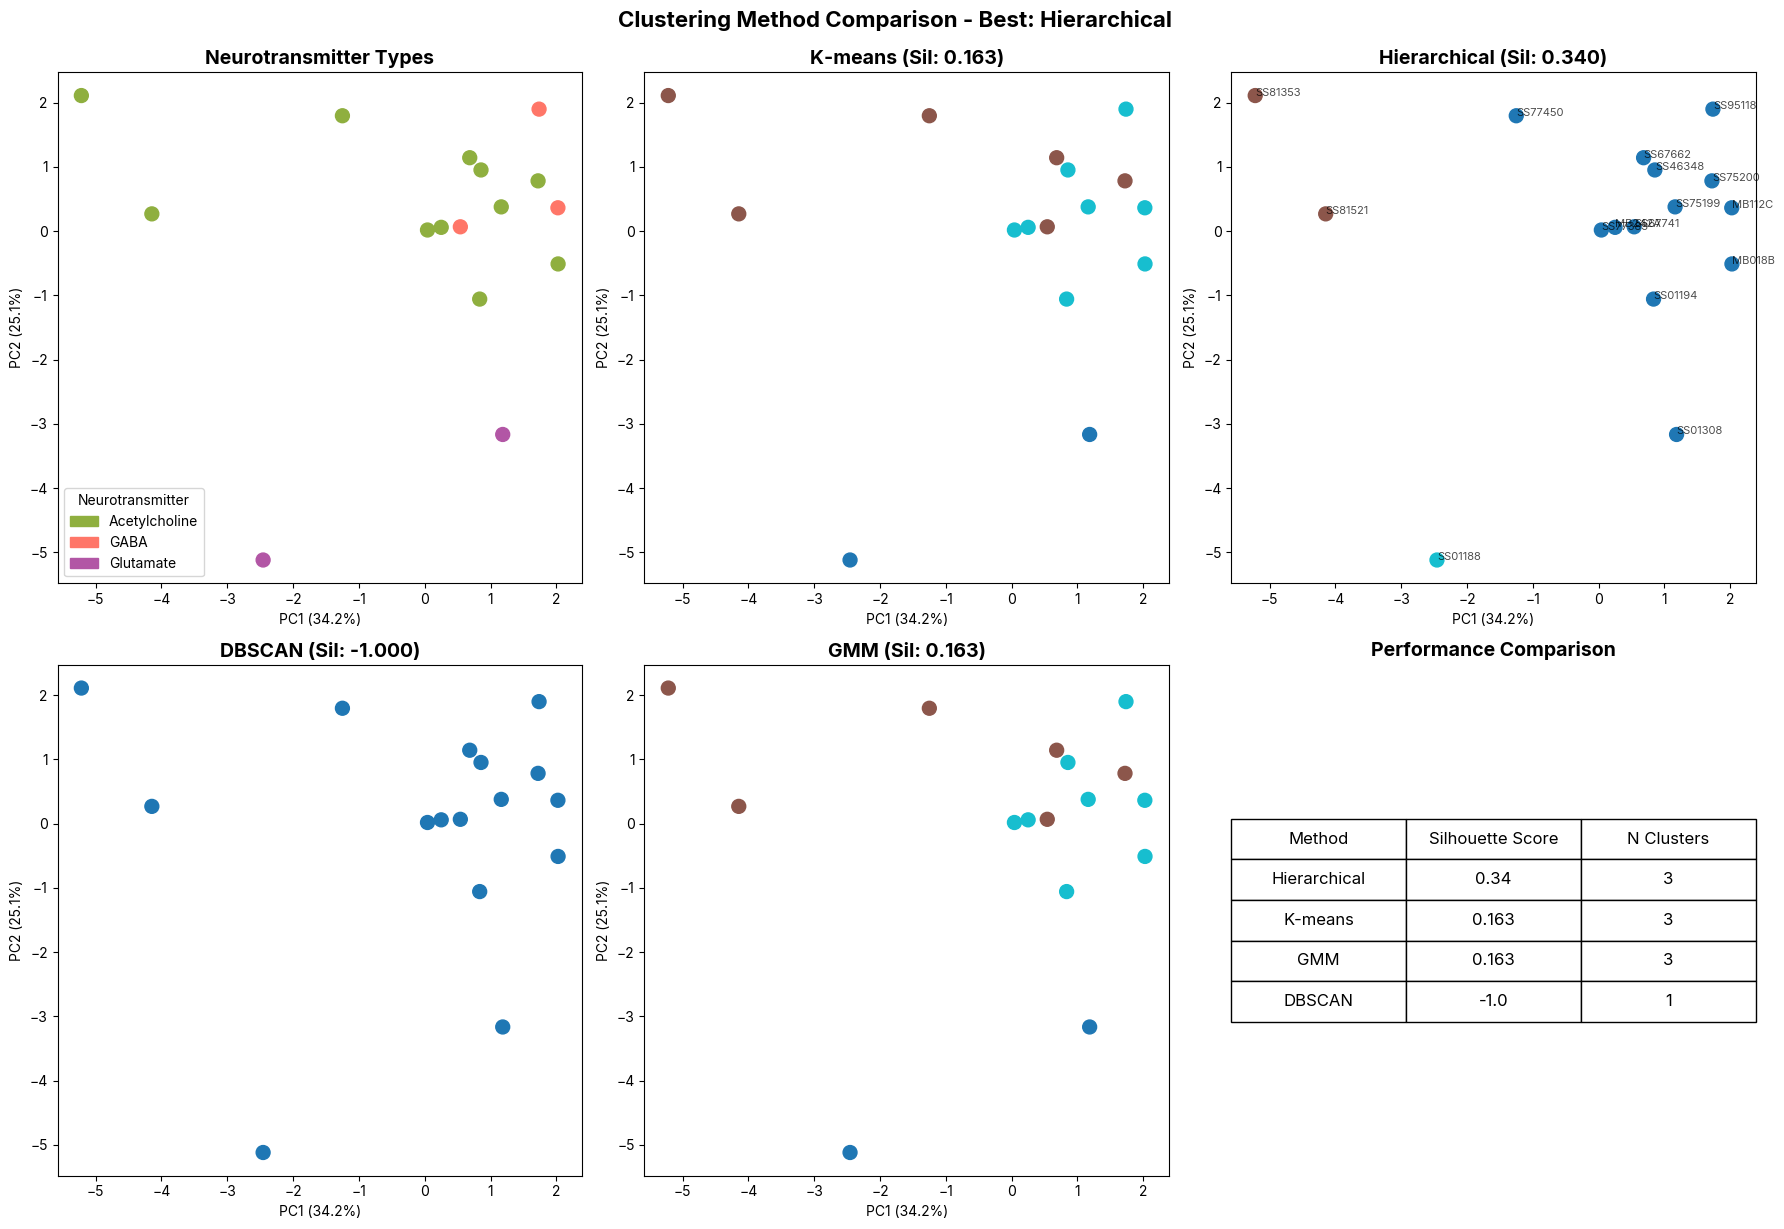

In [168]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#colors for plot 1
nt_color_map = {
    'Acetylcholine': "#8FAF3F",  # Red
    'GABA': "#FF7668",           # Purple
    'Glutamate': "#B256A5"       # Brown
}

nt_cat = df_clustermbons_clustered['NT'].astype('category')
point_colors = [nt_color_map[nt] for nt in df_clustermbons_clustered['NT']]

# Neurotransmitter types (reference)
axes[0,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=point_colors, s=100)
axes[0,0].set_title('Neurotransmitter Types', fontsize=14, weight='bold')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

handles = [mpatches.Patch(color=nt_color_map[nt], label=nt) 
           for nt in nt_cat.cat.categories]
axes[0,0].legend(handles=handles, title='Neurotransmitter')

# K-means
axes[0,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['KMeans'], cmap='tab10', s=100)
axes[0,1].set_title(f'K-means (Sil: {sil_kmeans:.3f})', fontsize=14, weight='bold')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Hierarchical
axes[0,2].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['Hierarchical'], cmap='tab10', s=100)
axes[0,2].set_title(f'Hierarchical (Sil: {sil_hierarchical:.3f})', fontsize=14, weight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# DBSCAN
axes[1,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['DBSCAN'], cmap='tab10', s=100)
axes[1,0].set_title(f'DBSCAN (Sil: {sil_dbscan:.3f})', fontsize=14, weight='bold')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# GMM
axes[1,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['GMM'], cmap='tab10', s=100)
axes[1,1].set_title(f'GMM (Sil: {sil_gmm:.3f})', fontsize=14, weight='bold')
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Results table
axes[1,2].axis('off')
table_data = results.sort_values('Silhouette Score', ascending=False).round(3)
table = axes[1,2].table(cellText=table_data.values, colLabels=table_data.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
axes[1,2].set_title('Performance Comparison', fontsize=14, weight='bold')

best_ax = None
if best_method == 'K-means':
    best_ax = axes[0,1]
elif best_method == 'Hierarchical': 
    best_ax = axes[0,2]
# elif best_method == 'DBSCAN':
#     best_ax = axes[1,0]
# elif best_method == 'GMM':
#     best_ax = axes[1,1]

if best_ax is not None:
    for i, mbon in enumerate(df_clustermbons_clustered.index):
        best_ax.annotate(mbon, (df_clustermbons_clustered['PCA1'].iloc[i], df_clustermbons_clustered['PCA2'].iloc[i]), 
                        fontsize=8, alpha=0.7)

plt.tight_layout()
plt.suptitle(f'Clustering Method Comparison - Best: {best_method}', fontsize=16, weight='bold', y=1.02)
#plt.savefig(filesavedir + date + '_clustering_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

## dendograms and beyond

In [73]:
n_clusters = 3

linkage_method = 'ward'  # Options: 'ward', 'average', 'complete', 'single'
distance_metric = 'euclidean'  # Options: 'euclidean', 'correlation', 'manhattan'

# Optional: Load connectivity matrix (set to None if you don't have one)
connectivity_file = None  # Example: "connectivity_matrix.csv"

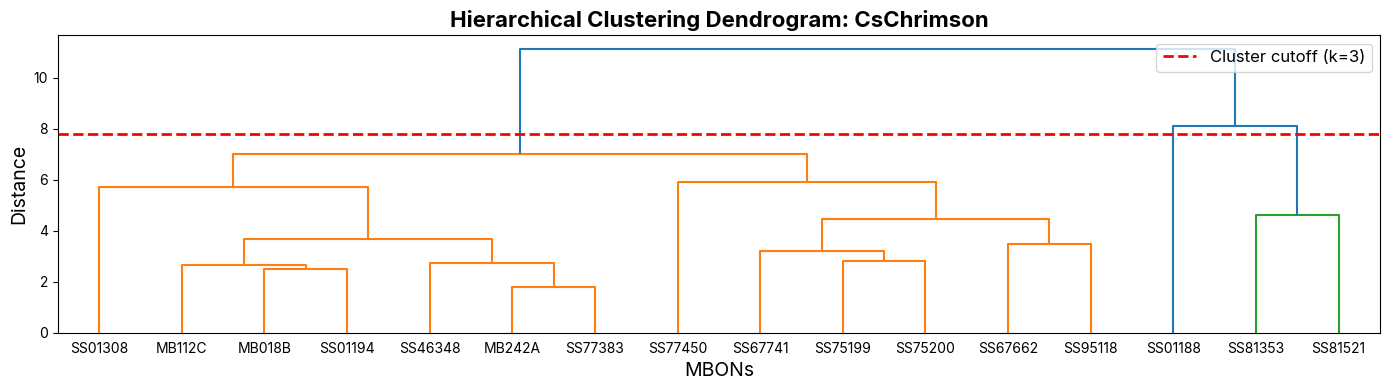

In [74]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx

df_nt_dendogram = datasettouse.drop(columns=['NT'])
scaler = StandardScaler()
df_nt_dendogram_scaled = scaler.fit_transform(df_nt_dendogram)
Z = linkage(df_nt_dendogram_scaled , method=linkage_method, metric=distance_metric)

plt.figure(figsize=(14, 4))
dend = dendrogram(Z, labels=df_nt_dendogram.index, 
                  leaf_font_size=10, leaf_rotation=0,
                  color_threshold=0.66*max(Z[:,2]))

plt.title(f'Hierarchical Clustering Dendrogram: ' + responderrename, 
         fontsize=16, fontweight='bold')
plt.xlabel('MBONs', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.axhline(y=0.7*max(Z[:,2]), c='red', linestyle='--', linewidth=2, 
           label=f'Cluster cutoff (k={n_clusters})')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [180]:
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# Add cluster labels to dataframe
data_with_clusters = df_nt_dendogram.copy()
data_with_clusters['Cluster'] = cluster_labels

print(f"Cluster assignments:")
print(data_with_clusters['Cluster'].value_counts().sort_index())

print(f"\nMBONs per cluster:")
for cluster_id in range(1, n_clusters+1):
    mbons = data_with_clusters[data_with_clusters['Cluster'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id} ({len(mbons)} MBONs):")
    print(f"  {', '.join(mbons)}")

# Save cluster assignments
#data_with_clusters.to_csv('mbon_cluster_assignments.csv')

Cluster assignments:
Cluster
1     2
2     2
3    12
Name: count, dtype: int64

MBONs per cluster:

Cluster 1 (2 MBONs):
  SS81353, SS81521

Cluster 2 (2 MBONs):
  SS01188, SS01308

Cluster 3 (12 MBONs):
  MB018B, MB112C, MB242A, SS01194, SS46348, SS67662, SS67741, SS75199, SS75200, SS77383, SS77450, SS95118


In [186]:
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
data_with_clusters = df_nt_dendogram.copy()
data_with_clusters['Cluster'] = cluster_labels


data_with_clusters['PI'] = df_nt_dendogram['PI_Hg_OSAR'] 
data_with_clusters['LAI'] = df_nt_dendogram['Light Attraction Index_Hg_OSAR']  

for cluster_id in range(1, n_clusters+1):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_id]
    
    mean_pi = cluster_data['PI'].mean()
    std_pi = cluster_data['PI'].std()
    mean_lai = cluster_data['LAI'].mean()
    std_lai = cluster_data['LAI'].std()
    
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  PI:  {mean_pi:.3f} ± {std_pi:.3f}")
    print(f"  LAI: {mean_lai:.3f} ± {std_lai:.3f}")
    
    #Optional: list individual MBON values
    for mbon in cluster_data.index:
        print(f"    {mbon}: PI={cluster_data.loc[mbon, 'PI']:.3f}, LAI={cluster_data.loc[mbon, 'LAI']:.3f}")

# Statistical test - do clusters differ in valence?
from scipy import stats

pi_by_cluster = [data_with_clusters[data_with_clusters['Cluster'] == i]['PI'].values 
                  for i in range(1, n_clusters+1)]
lai_by_cluster = [data_with_clusters[data_with_clusters['Cluster'] == i]['LAI'].values 
                   for i in range(1, n_clusters+1)]

pi_anova = stats.f_oneway(*pi_by_cluster)
lai_anova = stats.f_oneway(*lai_by_cluster)

print(f"\n=== Statistical Tests ===")
print(f"PI differs between clusters: p = {pi_anova.pvalue:.4f}")
print(f"LAI differs between clusters: p = {lai_anova.pvalue:.4f}")


Cluster 1 (n=2):
  PI:  0.129 ± 0.159
  LAI: -0.113 ± 0.304
    SS81353: PI=0.017, LAI=-0.328
    SS81521: PI=0.241, LAI=0.102

Cluster 2 (n=2):
  PI:  0.316 ± 0.095
  LAI: -0.373 ± 0.153
    SS01188: PI=0.383, LAI=-0.264
    SS01308: PI=0.248, LAI=-0.481

Cluster 3 (n=12):
  PI:  -0.090 ± 0.378
  LAI: -0.019 ± 0.326
    MB018B: PI=0.403, LAI=0.284
    MB112C: PI=0.244, LAI=0.065
    MB242A: PI=-0.132, LAI=0.138
    SS01194: PI=0.254, LAI=0.298
    SS46348: PI=-0.467, LAI=0.041
    SS67662: PI=-0.320, LAI=-0.678
    SS67741: PI=0.543, LAI=0.443
    SS75199: PI=-0.499, LAI=-0.102
    SS75200: PI=-0.617, LAI=-0.020
    SS77383: PI=-0.097, LAI=-0.158
    SS77450: PI=-0.321, LAI=-0.535
    SS95118: PI=-0.072, LAI=-0.002

=== Statistical Tests ===
PI differs between clusters: p = 0.2988
LAI differs between clusters: p = 0.3608


KeyError: 'PC1'

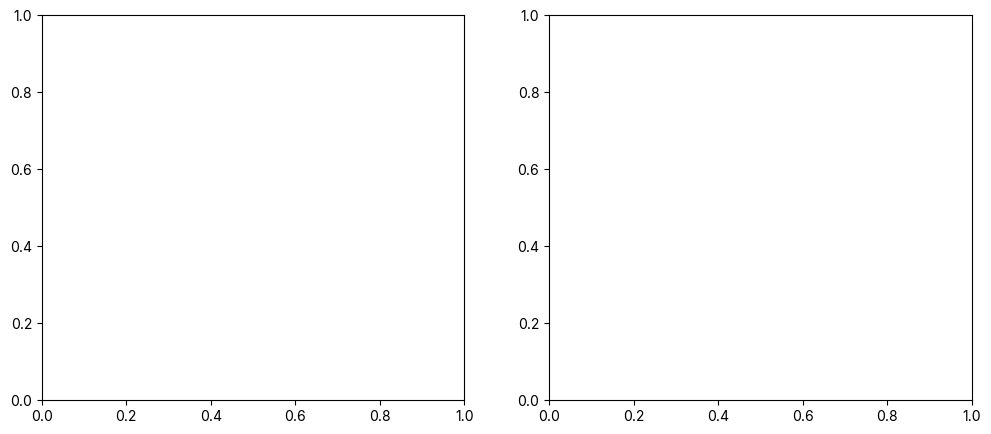

In [187]:
import matplotlib.pyplot as plt

# Create scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define cluster colors to match your PCA plot
colors = {1: 'brown', 2: 'cyan', 3: 'blue'}
cluster_names = {1: 'Escape specialists', 2: 'Movement disorganizers', 3: 'Climbing enhancers'}

# Plot 1: PC1 vs PI
ax1 = axes[0]
for cluster_id in range(1, n_clusters+1):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_id]
    ax1.scatter(cluster_data['PC1'], cluster_data['PI'], 
                c=colors[cluster_id], label=cluster_names[cluster_id], 
                s=100, alpha=0.7, edgecolors='black')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('PC1 (Motor specialization)', fontsize=12)
ax1.set_ylabel('Preference Index (PI)', fontsize=12)
ax1.set_title('Motor Specialization vs Valence', fontsize=14)
ax1.legend()

# Plot 2: PC2 vs LAI
ax2 = axes[1]
for cluster_id in range(1, n_clusters+1):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_id]
    ax2.scatter(cluster_data['PC2'], cluster_data['LAI'], 
                c=colors[cluster_id], label=cluster_names[cluster_id],
                s=100, alpha=0.7, edgecolors='black')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('PC2 (Bout organization)', fontsize=12)
ax2.set_ylabel('Light Attraction Index', fontsize=12)
ax2.set_title('Bout Organization vs Light Attraction', fontsize=14)

plt.tight_layout()
plt.show()

## PCA metric analysis

In [ ]:
# Standardize data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_nt_dendogram)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# Extract loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=df_nt_dendogram.columns
)

# Print variance explained
print("="*60)
print("PCA VARIANCE EXPLAINED")
print("="*60)
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"\nCumulative (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

# Save loadings
# loadings.to_csv('pca_loadings.csv')

ValueError: Shape of passed values is (13, 13), indices imply (2, 13)

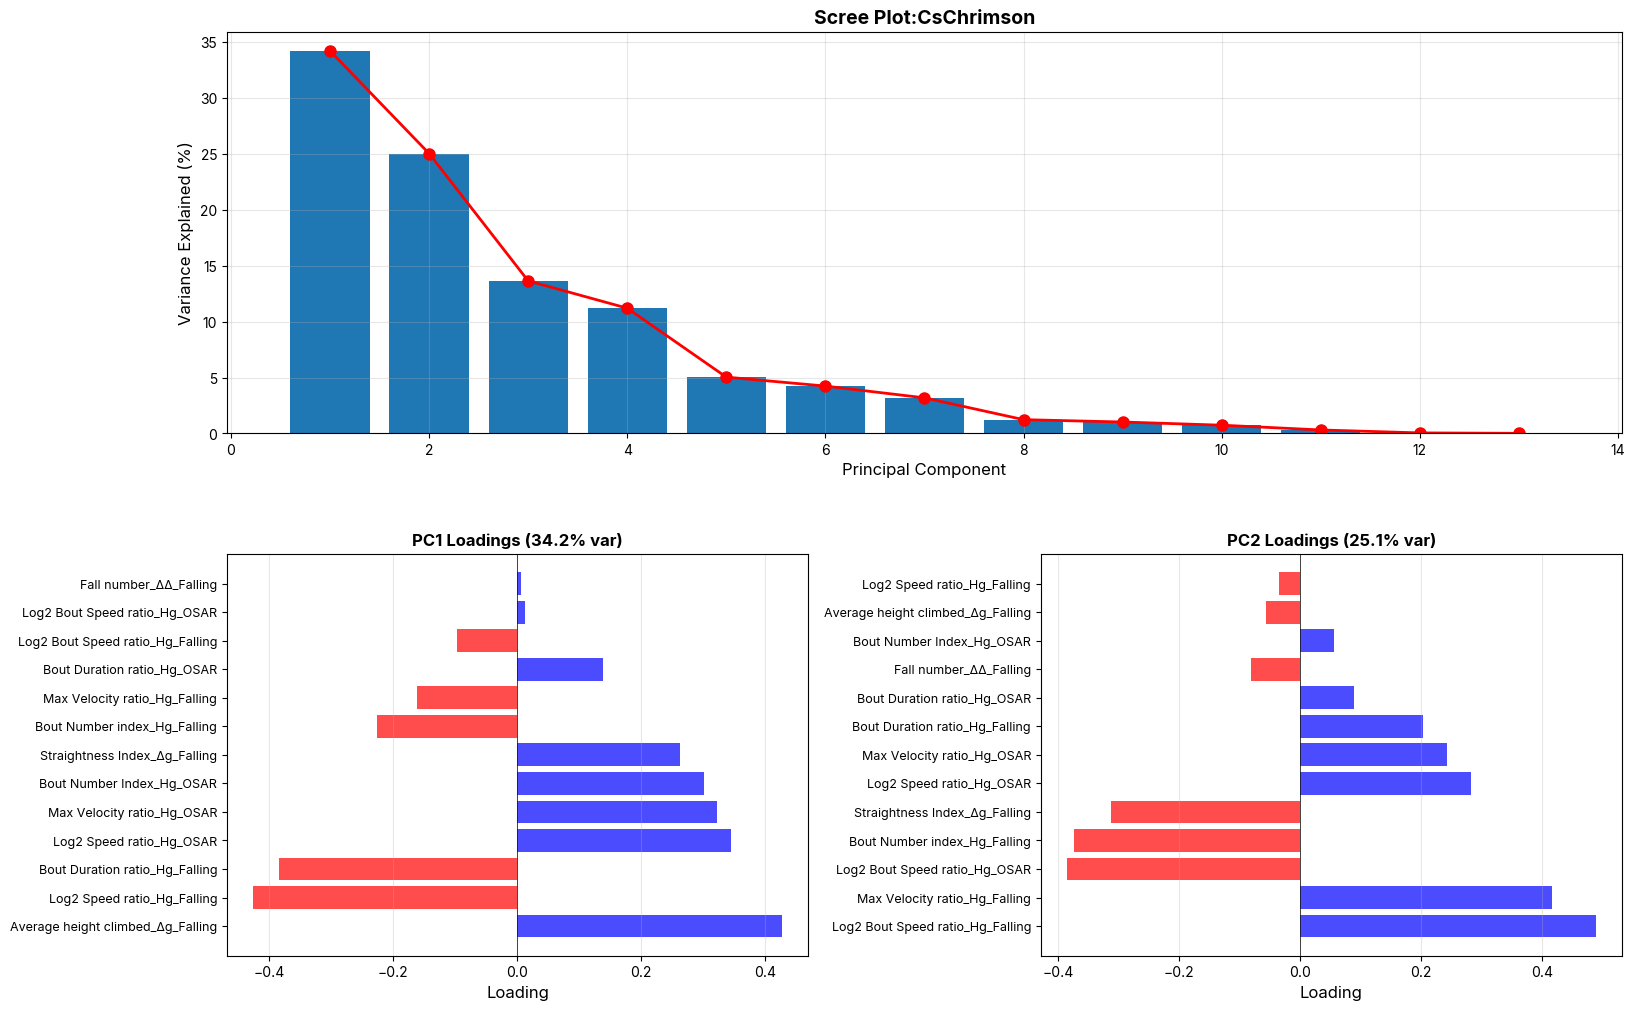


✓ PCA visualization saved as 'pca_loadings.png'


In [97]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.4)

# 1. Scree plot
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_*100)
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_*100, 'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained (%)', fontsize=12)
ax1.set_title('Scree Plot:' + responderrename, fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. PC1 loadings
ax2 = fig.add_subplot(gs[1, 0])
pc1_loadings = loadings['PC1'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc1_loadings]
ax2.barh(range(len(pc1_loadings)), pc1_loadings, color=colors, alpha=0.7)
ax2.set_yticks(range(len(pc1_loadings)))
ax2.set_yticklabels(pc1_loadings.index, fontsize=9)
ax2.set_xlabel('Loading', fontsize=12)
ax2.set_title(f'PC1 Loadings ({pca.explained_variance_ratio_[0]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# 3. PC2 loadings
ax3 = fig.add_subplot(gs[1, 1])
pc2_loadings = loadings['PC2'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc2_loadings]
ax3.barh(range(len(pc2_loadings)), pc2_loadings, color=colors, alpha=0.7)
ax3.set_yticks(range(len(pc2_loadings)))
ax3.set_yticklabels(pc2_loadings.index, fontsize=9)
ax3.set_xlabel('Loading', fontsize=12)
ax3.set_title(f'PC2 Loadings ({pca.explained_variance_ratio_[1]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3, axis='x')

plt.show()

print("\n✓ PCA visualization saved as 'pca_loadings.png'")

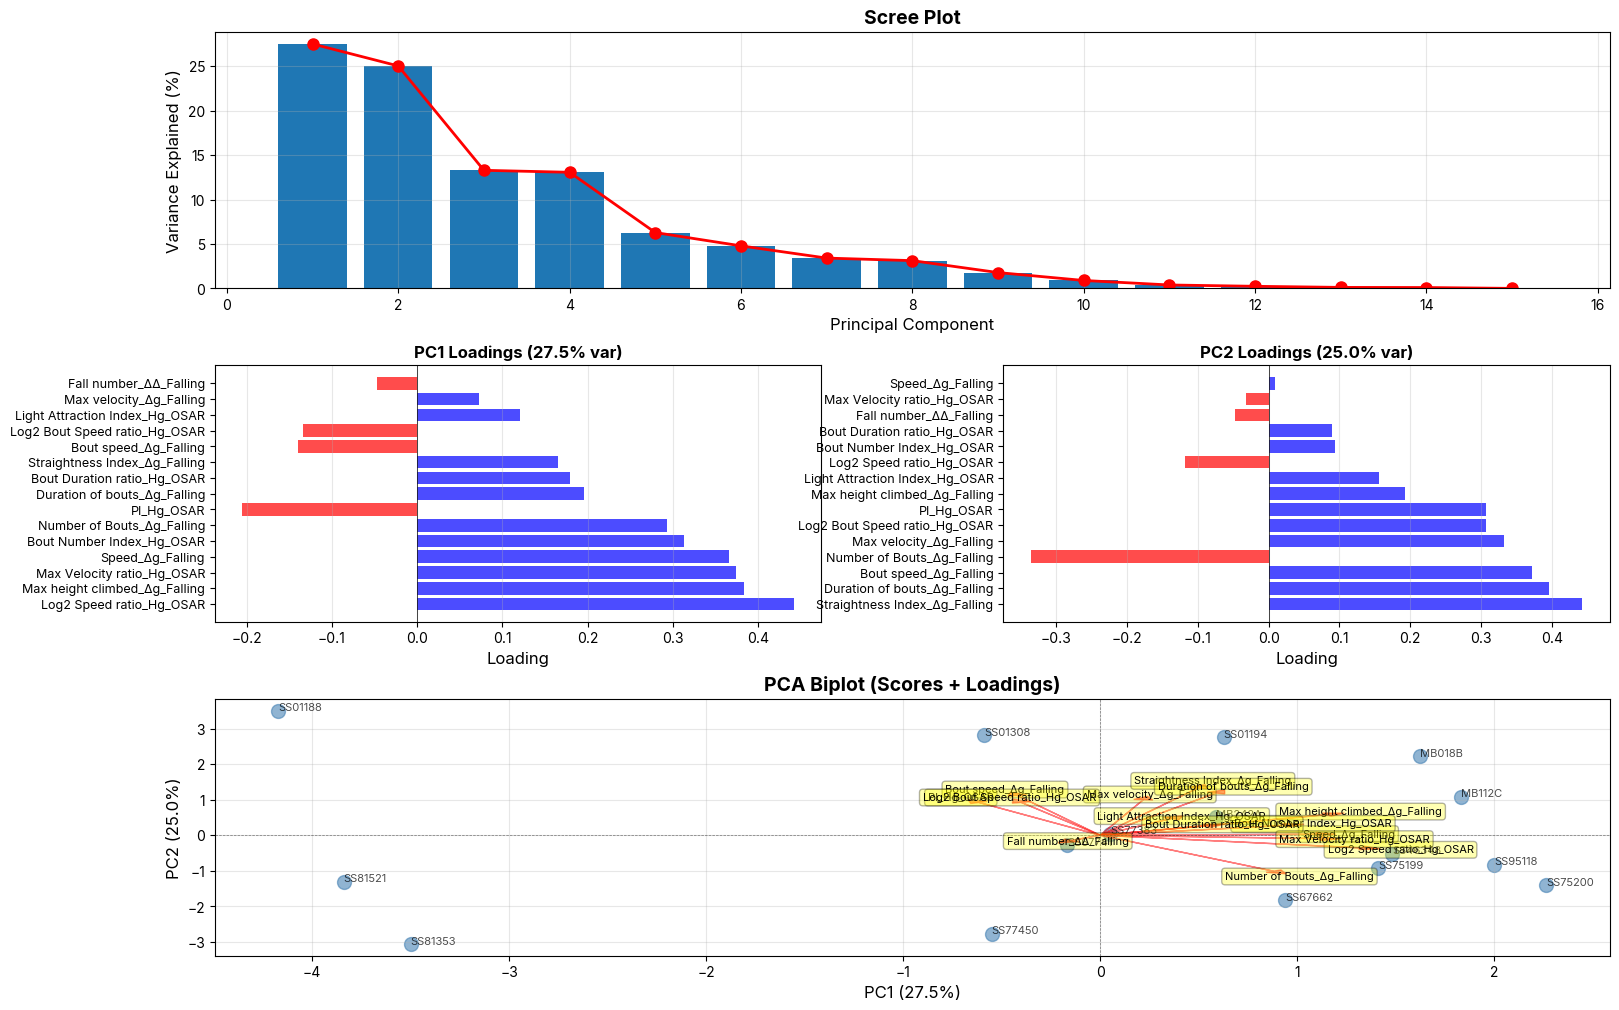


✓ PCA visualization saved as 'pca_loadings.png'


In [60]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Scree plot
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_*100)
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_*100, 'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained (%)', fontsize=12)
ax1.set_title('Scree Plot', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. PC1 loadings
ax2 = fig.add_subplot(gs[1, 0])
pc1_loadings = loadings['PC1'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc1_loadings]
ax2.barh(range(len(pc1_loadings)), pc1_loadings, color=colors, alpha=0.7)
ax2.set_yticks(range(len(pc1_loadings)))
ax2.set_yticklabels(pc1_loadings.index, fontsize=9)
ax2.set_xlabel('Loading', fontsize=12)
ax2.set_title(f'PC1 Loadings ({pca.explained_variance_ratio_[0]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# 3. PC2 loadings
ax3 = fig.add_subplot(gs[1, 1])
pc2_loadings = loadings['PC2'].sort_values(key=abs, ascending=False)
colors = ['red' if x < 0 else 'blue' for x in pc2_loadings]
ax3.barh(range(len(pc2_loadings)), pc2_loadings, color=colors, alpha=0.7)
ax3.set_yticks(range(len(pc2_loadings)))
ax3.set_yticklabels(pc2_loadings.index, fontsize=9)
ax3.set_xlabel('Loading', fontsize=12)
ax3.set_title(f'PC2 Loadings ({pca.explained_variance_ratio_[1]*100:.1f}% var)', 
              fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Biplot
ax4 = fig.add_subplot(gs[2, :])

# Plot scores
ax4.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, s=100, c='steelblue')

# Add MBON labels
for i, mbon in enumerate(df_nt_dendogram.index):
    ax4.annotate(mbon, (pca_result[i, 0], pca_result[i, 1]),
                fontsize=8, alpha=0.7)

# Plot loading vectors
scale = 3
for i, metric in enumerate(df_nt_dendogram.columns):
    ax4.arrow(0, 0, loadings.iloc[i, 0]*scale, loadings.iloc[i, 1]*scale,
             head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax4.text(loadings.iloc[i, 0]*scale*1.15, loadings.iloc[i, 1]*scale*1.15,
            metric, fontsize=8, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax4.set_title('PCA Biplot (Scores + Loadings)', fontsize=14, fontweight='bold')
ax4.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax4.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax4.grid(True, alpha=0.3)

plt.show()

print("\n✓ PCA visualization saved as 'pca_loadings.png'")

In [62]:
print("="*60)
print("TOP LOADINGS (by absolute value)")
print("="*60)

print("\nPC1 - Top 5 metrics:")
print(loadings['PC1'].abs().sort_values(ascending=False).head())

print("\nPC2 - Top 5 metrics:")
print(loadings['PC2'].abs().sort_values(ascending=False).head())

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("- Positive loading (blue): Metric increases with PC score")
print("- Negative loading (red): Metric decreases with PC score")
print("- High absolute value: Strong contribution to that PC")

TOP LOADINGS (by absolute value)

PC1 - Top 5 metrics:
Log2 Speed ratio_Hg_OSAR         0.442029
Max height climbed_Δg_Falling    0.383363
Max Velocity ratio_Hg_OSAR       0.374296
Speed_Δg_Falling                 0.365574
Bout Number Index_Hg_OSAR        0.313225
Name: PC1, dtype: float64

PC2 - Top 5 metrics:
Straightness Index_Δg_Falling    0.443228
Duration of bouts_Δg_Falling     0.395528
Bout speed_Δg_Falling            0.372578
Number of Bouts_Δg_Falling       0.336158
Max velocity_Δg_Falling          0.332436
Name: PC2, dtype: float64

INTERPRETATION:
- Positive loading (blue): Metric increases with PC score
- Negative loading (red): Metric decreases with PC score
- High absolute value: Strong contribution to that PC


## network diagrams

In [63]:
data_with_clusters

,Fall number_ΔΔ_Falling,Speed_Δg_Falling,Max height climbed_Δg_Falling,Bout speed_Δg_Falling,Max velocity_Δg_Falling,Straightness Index_Δg_Falling,Duration of bouts_Δg_Falling,Number of Bouts_Δg_Falling,PI_Hg_OSAR,Log2 Speed ratio_Hg_OSAR,Log2 Bout Speed ratio_Hg_OSAR,Light Attraction Index_Hg_OSAR,Bout Number Index_Hg_OSAR,Bout Duration ratio_Hg_OSAR,Max Velocity ratio_Hg_OSAR,Cluster
MBON,,,,,,,,,,,,,,,,
MB018B,0.076,-0.350,0.293,0.188,0.412,0.210,0.146,-0.384,0.402923,0.113780,-0.189276,0.284107,0.145590,0.155396,0.347169,1
MB112C,-0.456,-0.307,0.285,-0.329,-0.362,0.209,0.048,-0.016,0.244231,0.186355,0.392273,0.065169,0.171952,0.214931,0.395470,1
MB242A,-0.341,-0.413,-0.435,-0.291,-0.469,0.020,0.166,-0.600,-0.131655,0.062215,0.178585,0.138073,-0.117794,-0.002582,0.151006,1
SS01188,0.329,-0.945,-0.942,1.612,0.345,0.101,-0.077,-2.039,0.382887,-1.015328,0.428199,-0.264349,-0.754269,-0.238888,-0.468508,3
SS01194,-0.578,-0.550,0.237,0.318,0.308,0.407,0.169,-0.863,0.254055,-0.157406,-0.052071,0.297878,-0.148192,0.179373,0.084884,1
SS01308,0.009,-0.061,0.712,0.474,0.065,0.144,0.346,-0.637,0.248447,-0.559452,1.193882,-0.481216,-0.841967,-0.352970,0.063963,1
SS46348,-0.502,-0.609,0.200,-0.671,-0.175,0.081,-0.114,0.126,-0.467341,0.226340,0.020302,0.041174,-0.302430,-0.216989,0.336238,1
SS67662,0.036,0.235,-0.657,-0.165,0.064,-0.969,-0.348,0.491,-0.319966,-0.085534,-0.098383,-0.677690,0.101335,-0.233215,0.360790,1
SS67741,0.894,-0.241,0.151,-0.168,-0.167,-0.567,-0.787,0.340,0.542885,-0.435818,0.068477,0.443361,-0.014714,0.023694,-0.045407,1


In [64]:
# Create network graph
G = nx.Graph()

# Add nodes (MBONs)
for mbon in data_with_clusters.index:
    cluster = data_with_clusters.loc[mbon, 'Cluster']
    G.add_node(mbon, cluster=cluster)

# Add edges based on connectivity or correlation
if connectivity_file is not None:
    # Load connectivity matrix
    connectivity_matrix = pd.read_csv(connectivity_file, index_col=0)
    for i, mbon1 in enumerate(connectivity_matrix.index):
        for j, mbon2 in enumerate(connectivity_matrix.columns):
            if i < j and connectivity_matrix.iloc[i, j] > 0:
                G.add_edge(mbon1, mbon2, weight=connectivity_matrix.iloc[i, j])
    print("Using provided connectivity matrix for edges")
else:
    # Use correlation-based connectivity
    data_for_corr = data_with_clusters.drop('Cluster', axis=1)
    corr_matrix = data_for_corr.T.corr()
    
    threshold = 0.5  # Adjust this if needed
    for i, mbon1 in enumerate(corr_matrix.index):
        for j, mbon2 in enumerate(corr_matrix.columns):
            if i < j and abs(corr_matrix.iloc[i, j]) > threshold:
                G.add_edge(mbon1, mbon2, weight=abs(corr_matrix.iloc[i, j]))
    print(f"Using correlation-based edges (threshold={threshold})")

print(f"\nNetwork Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
if G.edges():
    print(f"  Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}")
    print(f"  Network density: {nx.density(G):.3f}")

Using correlation-based edges (threshold=0.5)

Network Statistics:
  Nodes: 16
  Edges: 18
  Average degree: 2.25
  Network density: 0.150


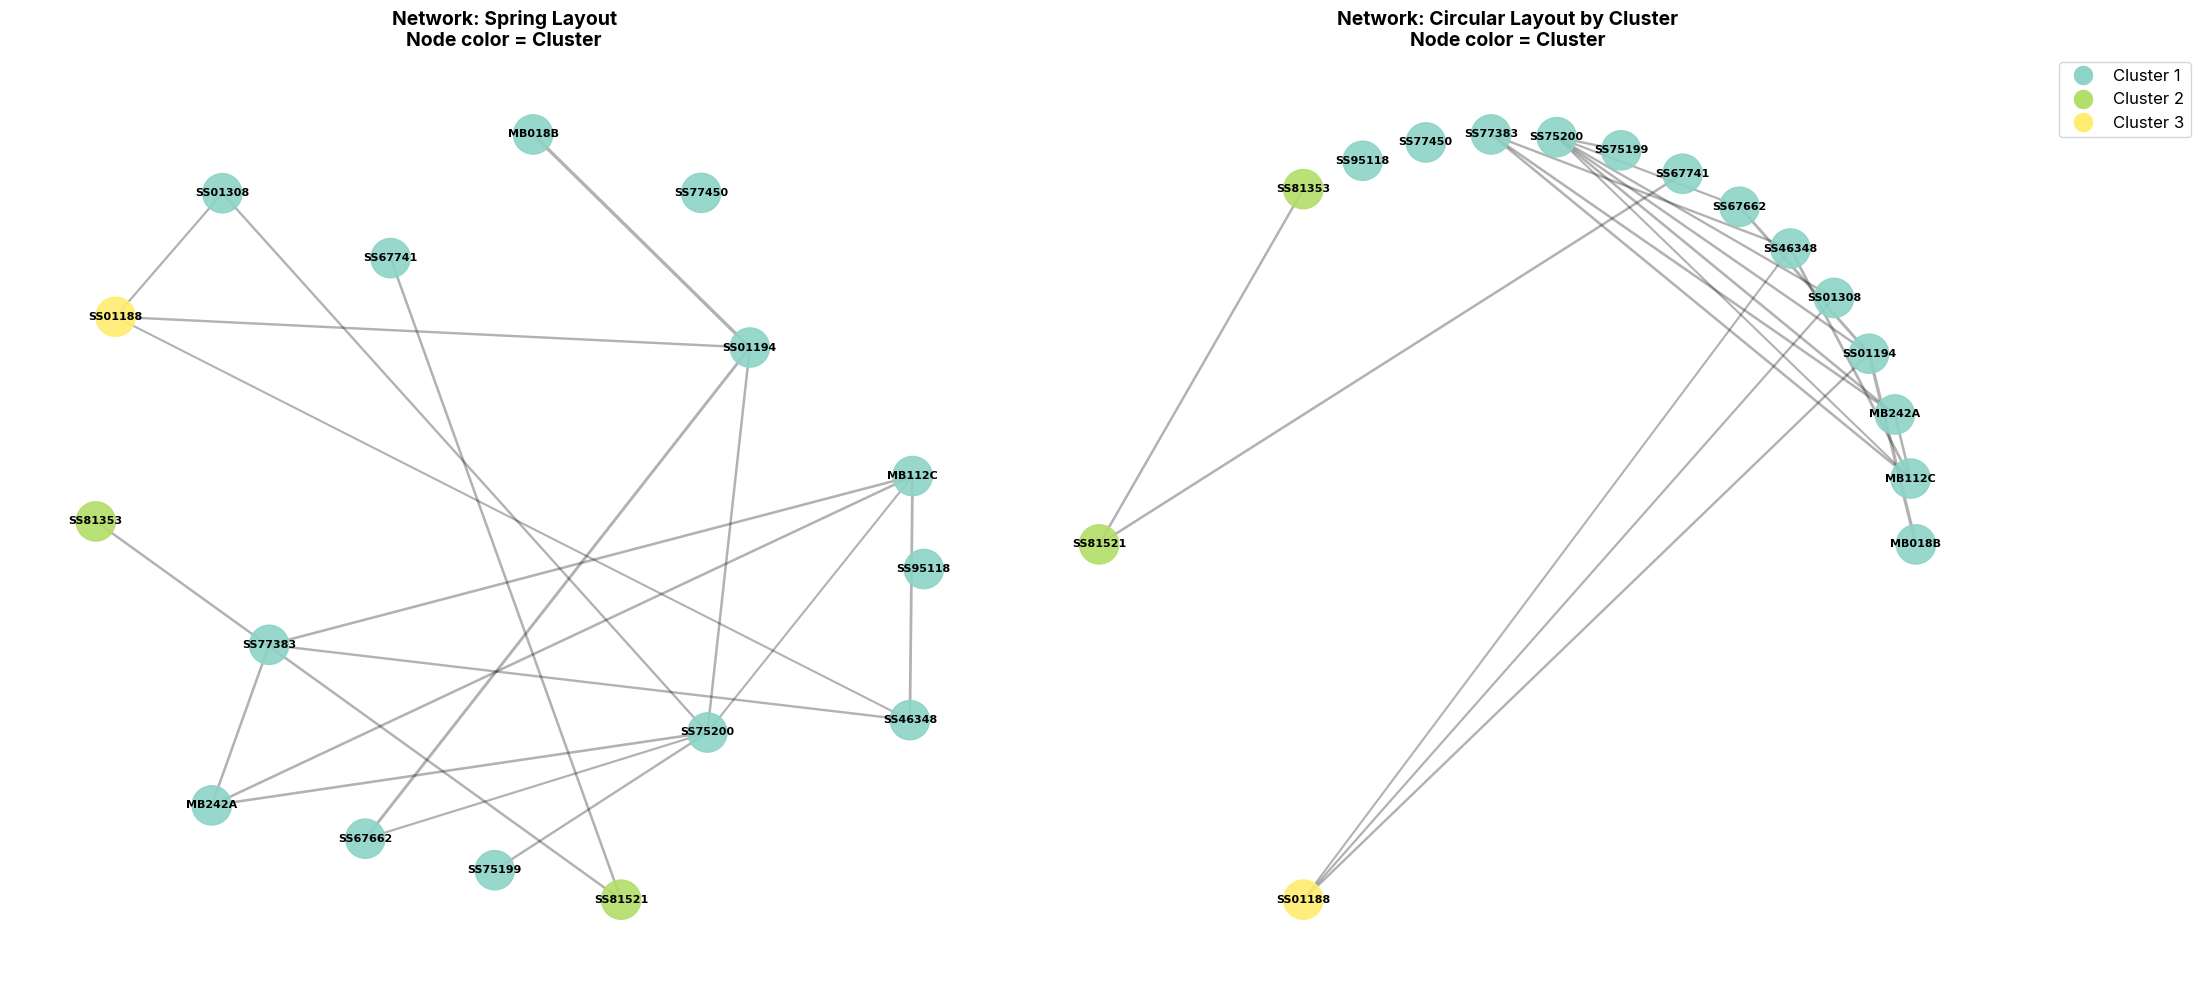


✓ Network diagram saved as 'mbon_network.png'


In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Define colors for clusters
cluster_colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))
color_map = {i+1: cluster_colors[i] for i in range(n_clusters)}
node_colors = [color_map[G.nodes[node]['cluster']] for node in G.nodes()]

# Layout 1: Spring layout
pos1 = nx.spring_layout(G, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(G, pos1, node_color=node_colors, node_size=800, 
                      alpha=0.9, ax=ax1)
nx.draw_networkx_labels(G, pos1, font_size=8, font_weight='bold', ax=ax1)

if G.edges():
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    nx.draw_networkx_edges(G, pos1, alpha=0.3, width=[w*3 for w in weights], ax=ax1)

ax1.set_title('Network: Spring Layout\nNode color = Cluster', 
              fontsize=14, fontweight='bold')
ax1.axis('off')

# Layout 2: Circular layout grouped by cluster
pos2 = {}
cluster_nodes = {}
for node in G.nodes():
    cluster = G.nodes[node]['cluster']
    if cluster not in cluster_nodes:
        cluster_nodes[cluster] = []
    cluster_nodes[cluster].append(node)

angle = 0
for cluster in sorted(cluster_nodes.keys()):
    nodes = cluster_nodes[cluster]
    cluster_angle_step = (2 * np.pi / n_clusters) / len(nodes)
    for i, node in enumerate(nodes):
        x = np.cos(angle + i * cluster_angle_step)
        y = np.sin(angle + i * cluster_angle_step)
        pos2[node] = (x, y)
    angle += 2 * np.pi / n_clusters

nx.draw_networkx_nodes(G, pos2, node_color=node_colors, node_size=800,
                      alpha=0.9, ax=ax2)
nx.draw_networkx_labels(G, pos2, font_size=8, font_weight='bold', ax=ax2)

if G.edges():
    nx.draw_networkx_edges(G, pos2, alpha=0.3, width=[w*3 for w in weights], ax=ax2)

ax2.set_title('Network: Circular Layout by Cluster\nNode color = Cluster', 
              fontsize=14, fontweight='bold')
ax2.axis('off')

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color_map[i+1], 
                              markersize=15, label=f'Cluster {i+1}')
                  for i in range(n_clusters)]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=12,
          bbox_to_anchor=(1.05, 1))

plt.tight_layout()

plt.show()

print("\n✓ Network diagram saved as 'mbon_network.png'")

In [41]:
# Calculate pairwise distances between clusters
cluster_distances = pdist(cluster_means, metric='euclidean')
dist_matrix = squareform(cluster_distances)

# Convert to similarity
max_dist = np.max(dist_matrix)
similarity_matrix = 1 - (dist_matrix / max_dist)

# Create graph
G_cluster = nx.Graph()

for i in range(n_clusters):
    G_cluster.add_node(f"Cluster {i+1}")

# Add edges (similarity > 0.3)
threshold = 0.3
for i in range(n_clusters):
    for j in range(i+1, n_clusters):
        if similarity_matrix[i, j] > threshold:
            G_cluster.add_edge(f"Cluster {i+1}", f"Cluster {j+1}", 
                              weight=similarity_matrix[i, j])

# Plot
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_cluster, k=3, iterations=50)

nx.draw_networkx_nodes(G_cluster, pos, node_size=3000, node_color='lightblue',
                      alpha=0.9)
nx.draw_networkx_labels(G_cluster, pos, font_size=14, font_weight='bold')

if G_cluster.edges():
    edges = G_cluster.edges()
    weights = [G_cluster[u][v]['weight'] for u, v in edges]
    nx.draw_networkx_edges(G_cluster, pos, width=[w*5 for w in weights], 
                          alpha=0.6)
    
    edge_labels = {(u, v): f"{G_cluster[u][v]['weight']:.2f}" for u, v in edges}
    nx.draw_networkx_edge_labels(G_cluster, pos, edge_labels, font_size=10)

plt.title('Cluster Similarity Network\n(Edge width = similarity)', 
         fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Cluster similarity network saved as 'cluster_similarity_network.png'")

NameError: name 'cluster_means' is not defined